In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k8'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    # summary = summary[summary.cluster_size > 4]
    c0 = 857708
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/rheum/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
as_seqs = [
    'CASSVGLFSTDTQYF',
    'CASSVGLYSTDTQYF',
    'CASSAGLFSTDTQYF',
    'CASSAGLYSTDTQYF',
    'CASSLGLFSTDTQYF',
    'CASSLGLYSTDTQYF',
    'CASSPGLFSTDTQYF',
    'CASSPGLYSTDTQYF'
]
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [6]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [7]:
vdjdb

A dataset of 8 clonotypes and 1 clusters

In [8]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k8'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x, threshold=1):
    return len(vdjdb.get_matching_clonotypes(x, threshold=threshold))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [11]:
metadata = pd.read_csv("/projects/immunestatus/rheum/airr_format/metadata.tsv", sep='\t')

In [12]:
metadata

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
...,...,...,...,...,...,...,...,...
63,Vol,as,pos,NaN,PBMC,NaN,as_Vol_PB_F,bulk
64,ZN,hd,pos,NaN,PBMC,NaN,hd_ZN_PB_F,bulk
65,Zakh,as,pos,NaN,PBMC,NaN,as_Zakh_PB_F,bulk
66,Zbot,hd,pos,NaN,PBMC,NaN,hd_Zbot_PB_F,bulk


In [13]:
metadata_h = metadata[metadata.disease_status != 'as']
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [14]:
metadata = metadata[(metadata.disease_status == 'as') & (~metadata.sample_name.str.contains('CD8'))]

In [15]:
samples = metadata.sample_name
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
51          as_Mikh_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [16]:
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample)
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info


    sample: as_Abd_PB_F
    clusters: 23071
    overall from background: 857708
    overall from sample: 102283
    

    sample: as_Abr_PB_F
    clusters: 21895
    overall from background: 857708
    overall from sample: 65178
    

    sample: as_Ash-110_PB_F_p0
    clusters: 26309
    overall from background: 857708
    overall from sample: 220160
    

    sample: as_Ash-111_PB_F_p0
    clusters: 26025
    overall from background: 857708
    overall from sample: 211288
    

    sample: as_Bal_PB_F
    clusters: 25908
    overall from background: 857708
    overall from sample: 202780
    

    sample: as_Bel_PB_F
    clusters: 22022
    overall from background: 857708
    overall from sample: 75228
    

    sample: as_Bost_PB_F
    clusters: 28779
    overall from background: 857708
    overall from sample: 302672
    

    sample: as_Chaad_PB_F
    clusters: 20982
    overall from background: 857708
    overall from sample: 34613
    

    sample: as_Dv_PB_F
    clusters: 3422

In [17]:
df = sample_to_data['as_i70_PB_F'][0]

In [18]:
import seaborn as sns

In [19]:
df.cluster_size.sum()

128385

In [20]:
df.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue,vdjdb
13342,13342,3,0,3,1.000000,False
13318,13318,3,0,3,1.000000,False
13319,13319,3,0,3,1.000000,False
13320,13320,3,0,3,1.000000,False
13321,13321,3,0,3,1.000000,False
...,...,...,...,...,...,...
76,76,238,10,228,0.626757,False
3271,3271,239,6,233,0.958857,False
202,202,258,23,235,0.001495,False
291,291,371,25,346,0.029640,False


<Axes: xlabel='cluster_size', ylabel='Count'>

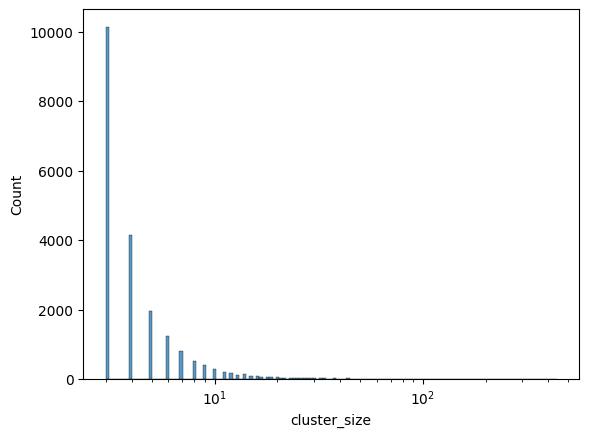

In [21]:
sns.histplot(df[['cluster_id', 'cluster_size']].drop_duplicates().cluster_size, log_scale=True)


In [22]:
import pandas as pd
import numpy as np
from scipy.stats import binom
from statsmodels.nonparametric.kde import KDEUnivariate

def compute_enrichment_local_fdr_binomial(df, sample_overall, background_overall):
    results = []

    # Вычисляем статистику напрямую на биномиальном распределении
    for _, row in df.iterrows():
        cluster_id = row['cluster_id']
        a = row['sample']
        b = row['background']

        p = b / background_overall
        expected = sample_overall * p

        percentile = binom.cdf(a, n=sample_overall, p=p)
        statistic = 2 * (percentile - 0.5)  # симметричная статистика, центрирована вокруг 0

        fold_enrichment = (a / sample_overall) / ((b + 1e-9) / background_overall)
        log_fold_enrichment = np.log2(fold_enrichment)
        
        z = (background_overall * a - sample_overall * b) / np.sqrt(sample_overall * b * (background_overall-b))
        
        results.append({
            'cluster_id': cluster_id,
            'sample': a,
            'background': b,
            'statistic': statistic,
            'log_fold_enrichment': log_fold_enrichment,
            'z': z
        })

    result_df = pd.DataFrame(results)
    return result_df

    # Оценка null-распределения (центральные значения около 0)
    # null_stat = result_df.loc[result_df['statistic'].abs() < 0.2, 'statistic']

#     # KDE всей выборки
#     kde = KDEUnivariate(result_df['statistic'])
#     kde.fit()
#     f = kde.evaluate(result_df['statistic'])

#     # KDE null-распределения
#     kde_null = KDEUnivariate(null_stat)
#     kde_null.fit()
#     f0 = kde_null.evaluate(result_df['statistic'])

#     pi0 = len(null_stat) / len(result_df)

#     result_df['local_fdr'] = pi0 * f0 / f

    # return result_df[['cluster_id', 'statistic', 'log_fold_enrichment', 'local_fdr']]


In [23]:
t = compute_enrichment_local_fdr_binomial(sample_to_data['as_Shep_PB_F'][0], 
                                          sample_overall=sample_to_data['as_Shep_PB_F'][2], 
                                          background_overall=sample_to_data['as_Shep_PB_F'][1])
t

/scratch/ipykernel_3630097/2548561717.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  z = (background_overall * a - sample_overall * b) / np.sqrt(sample_overall * b * (background_overall-b))
/scratch/ipykernel_3630097/2548561717.py:22: RuntimeWarning: divide by zero encountered in log2
  log_fold_enrichment = np.log2(fold_enrichment)


,cluster_id,sample,background,statistic,log_fold_enrichment,z
0,0,85,175,0.991171,0.416871,2.673563
1,1,1,2,0.669061,0.458691,0.319281
2,2,2,4,0.639966,0.458691,0.451533
3,3,4,16,-0.380592,-0.541309,-0.754830
4,4,18,62,-0.602179,-0.325580,-0.959526
...,...,...,...,...,...,...
28671,28671,1,2,0.669061,0.458691,0.319281
28672,28672,1,2,0.669061,0.458691,0.319281
28673,28673,0,3,-0.328556,-inf,-1.044736
28674,28674,1,2,0.669061,0.458691,0.319281


In [24]:
import seaborn as sns

<Axes: xlabel='z', ylabel='Count'>

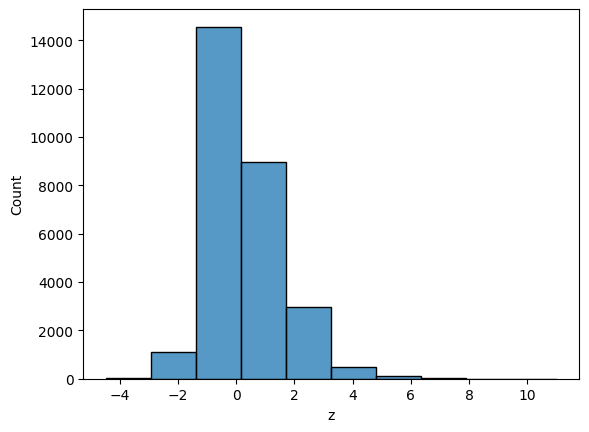

In [25]:
sns.histplot(t.z, bins=10)

<Axes: >

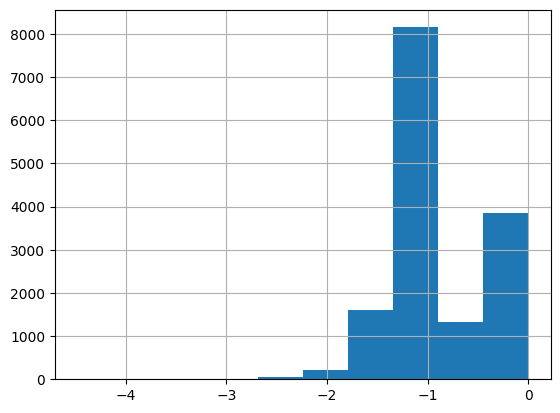

In [26]:
t[t.log_fold_enrichment < 0].z.hist()

<Axes: xlabel='z', ylabel='Count'>

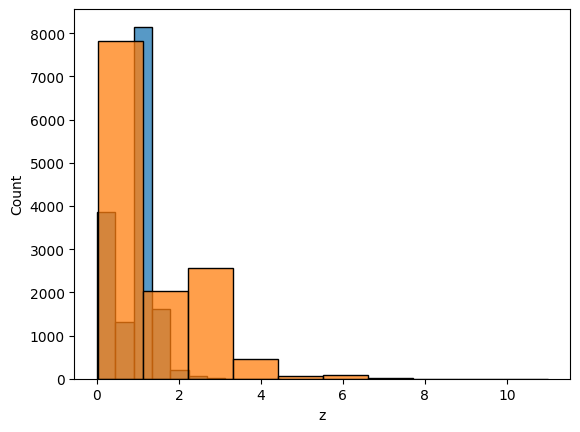

In [27]:
sns.histplot(-t[t.log_fold_enrichment < 0].z, bins=10)
sns.histplot(t[t.log_fold_enrichment > 0].z, bins=10)

In [28]:
from statsmodels.nonparametric.kde import KDEUnivariate

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency, binom
import matplotlib.pyplot as plt
import seaborn as sns

def compute_enrichment_pvalues(df, sample_overall, background_overall, method='z'):
    """
    df: DataFrame с колонками ['cluster_id', 'cluster_size', 'sample', 'background']
    sample_overall: общее число клонотипов в sample
    background_overall: общее число клонотипов в background
    method: 'fisher' | 'chi2' | 'binomial'
    """
    results = []

    for _, row in df.iterrows():
        cluster_id = row['cluster_id']
        a = row['sample']  # В кластере, из sample
        b = row['background']  # В кластере, из background
        c = sample_overall - a  # Вне кластера, из sample
        d = background_overall - b  # Вне кластера, из background

        if 'fisher' in method:
            _, pval = fisher_exact([[a, b], [c, d]])
        # elif method == 'chi2':
        #     _, pval, _, _ = chi2_contingency([[a, b], [c, d]])
        elif method == 'binomial':
            p = b / background_overall
            pval = min(binom.sf(k=a, n=sample_overall, p=p), binom.cdf(k=a, n=sample_overall, p=p))
        elif method == 'z':
            p = b / background_overall
            z = (background_overall * a - sample_overall * b) / np.sqrt(sample_overall * (b+1e-6) * (background_overall-b))
            pval = 2 * (1 - norm.cdf(np.abs(z)))
        else:
            raise ValueError("method must be one of 'fisher', 'chi2', 'binomial'")

        fold_enrichment = (a / sample_overall) / ((b + 1e-9) / background_overall)
        results.append({'cluster_id': cluster_id, 'pvalue': pval, 'fold_enrichment': fold_enrichment})

    return pd.DataFrame(results)


In [30]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_volcano(df, pval_threshold=0.05, fold_threshold=2, ax=None):
    df = df.copy()

    if 'vdjdb' not in df.columns:
        raise ValueError("DataFrame должен содержать колонку 'vdjdb'")

    # Преобразования
    df['log10_pval'] = -np.log10(df['pvalue'] + 1e-10)
    df['log2_fc'] = np.log2(df['fold_enrichment'] + 1e-5)
    df['significant'] = (df['pvalue'] < pval_threshold) & (df['fold_enrichment'] > fold_threshold)
    

    # Цветовая кодировка
    def assign_color(row):
        if row['significant'] and row['vdjdb']:
            return 'sign_vdjdb' #'#084594'  # тёмно-синий
        elif row['significant']:
            return 'sign'#'#4292c6'  # голубой
        elif row['vdjdb']:
            return 'vdjdb'#'#fdbb84'  # оранжевый
        else:
            return 'no'#'#ffffb2'  # бледно-жёлтый
    
    colors = {
        'sign_vdjdb': '#084594',  # тёмно-синий
        'sign': '#4292c6',  # голубой
        'vdjdb': '#fdbb84',  # оранжевый
        'no': '#ffffb2'  # бледно-жёлтый
    }
    
    df['label'] = df.apply(assign_color, axis=1)

    # Порог Бонферрони
    bonferroni_thresh = pval_threshold / len(df)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    num_significant = df['significant'].sum()
    num_significant_bonf = (df['pvalue'] < bonferroni_thresh).sum()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Отрисовка всех, кроме as_pattern
    base_df = df[~df['vdjdb']]
    sns.scatterplot(
        data=base_df,
        x='log2_fc',
        y='log10_pval',
        hue='label',
        style='vdjdb',
        palette=colors,
        markers={True: 's', False: '.'},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        s=70,
        alpha=0.85,
        legend=False  # потом отдельно добавим легенду
    )

    # Отрисовка as_pattern поверх
    pattern_df = df[df['vdjdb']]
    sns.scatterplot(
        data=pattern_df,
        x='log2_fc',
        y='log10_pval',
        hue='label',
        style='vdjdb',
        palette=colors,
        markers={True: 's', False: '.'},
        edgecolor='red',  # или другой яркий цвет
        linewidth=0.5,
        ax=ax,
        s=120,  # увеличенный размер
        alpha=1.0,
        legend=False
    )
    # Линии порогов
    ax.axvline(np.log2(fold_threshold), ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'Significant clusters: {num_significant}, after Bonferroni: {num_significant_bonf}')
    ax.legend()

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


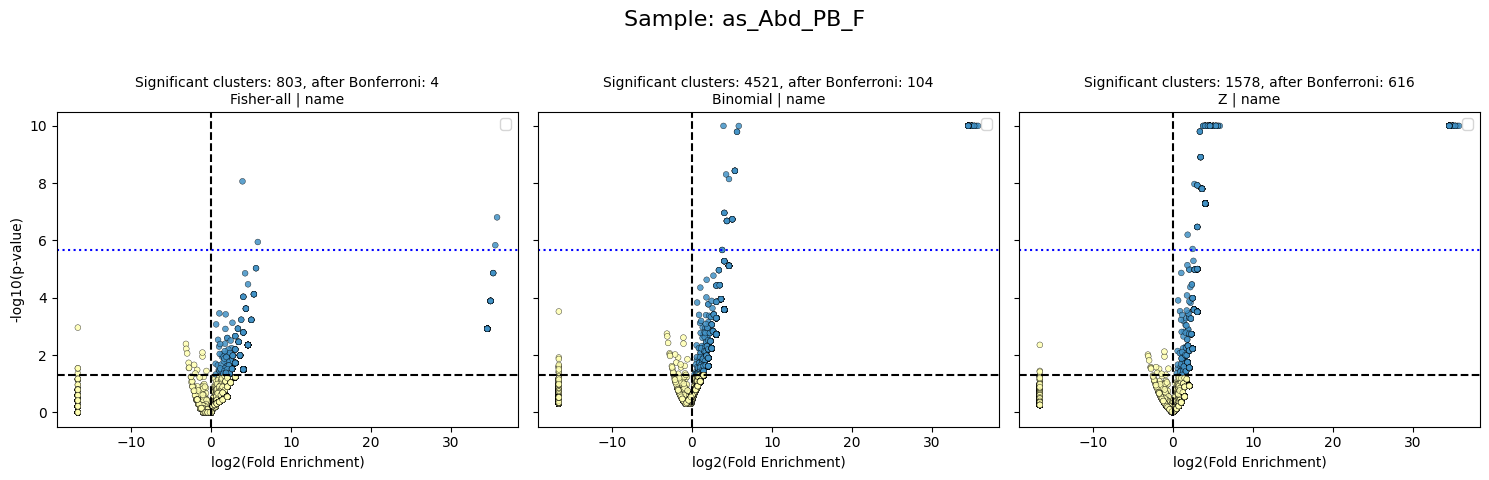

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


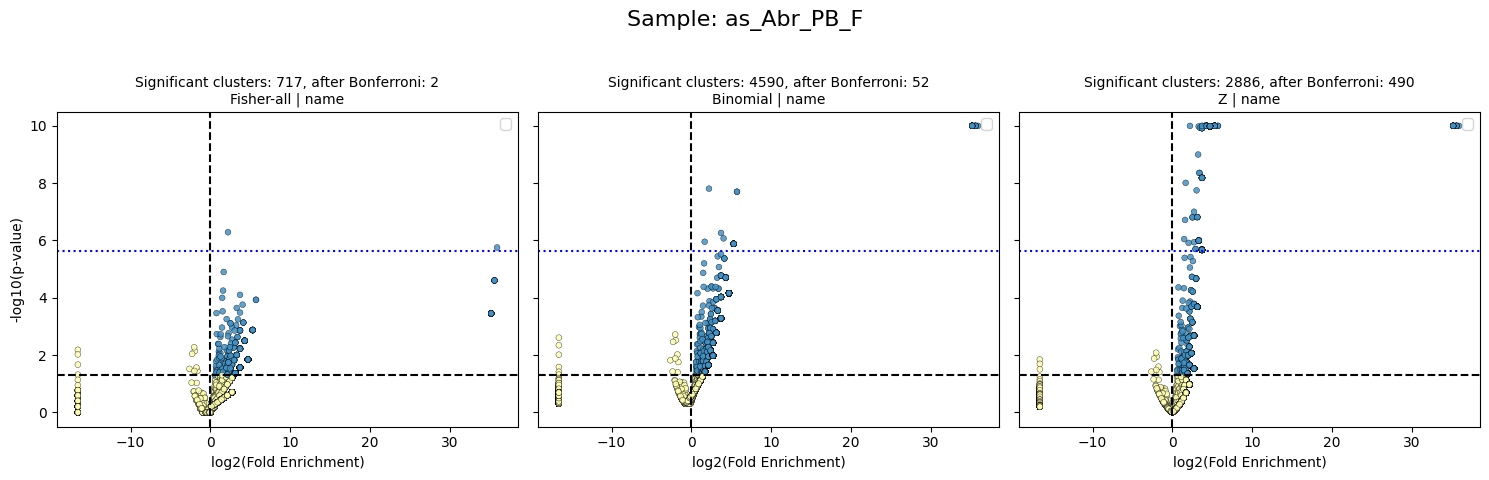

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


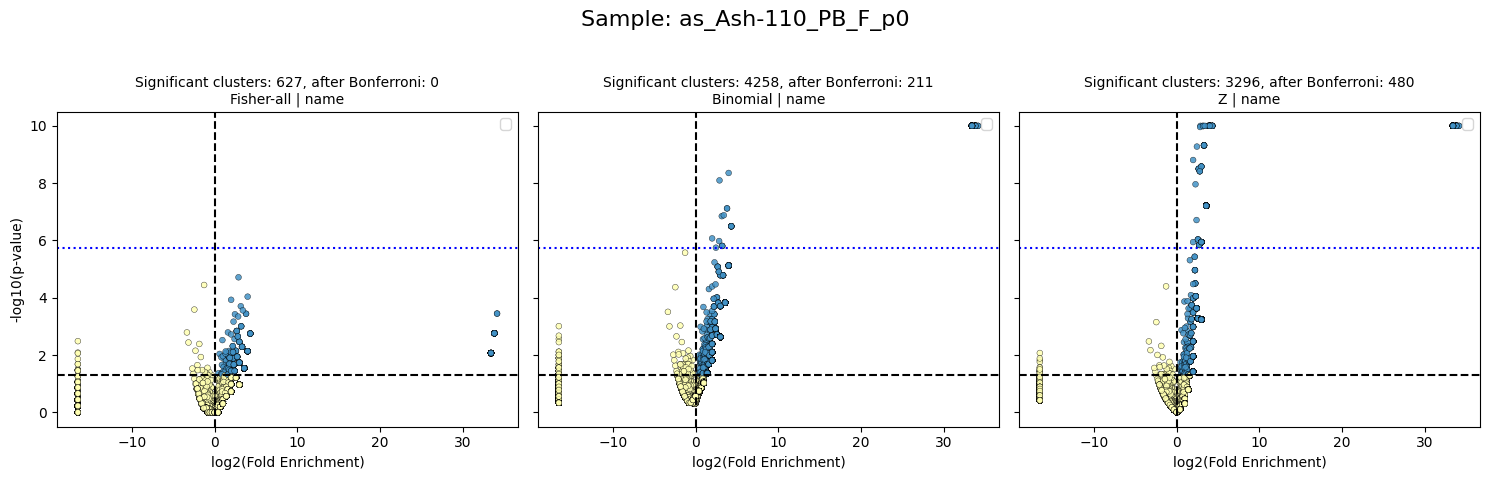

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


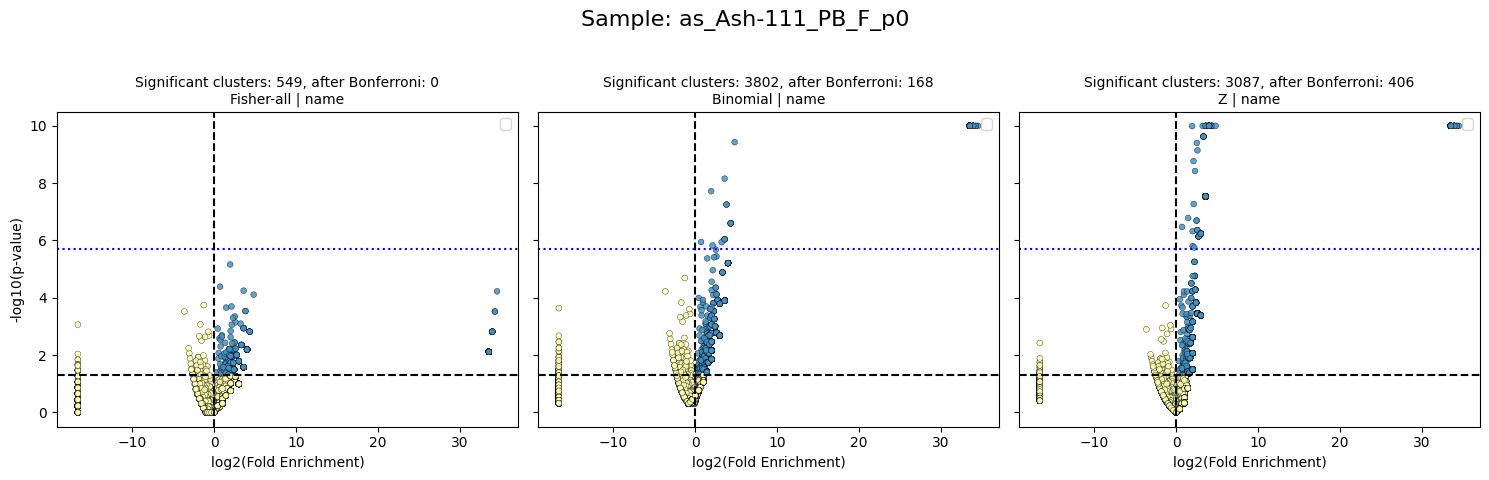

     cluster_id    pvalue  fold_enrichment  vdjdb
488         488  0.028551         5.639662   True
668         668  0.009030         4.229747   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id    pvalue  fold_enrichment  vdjdb
488         488  0.000833         5.639662   True
668         668  0.000325         4.229747   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id    pvalue  fold_enrichment  vdjdb
488         488  0.000093         5.639662   True
668         668  0.000033         4.229747   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


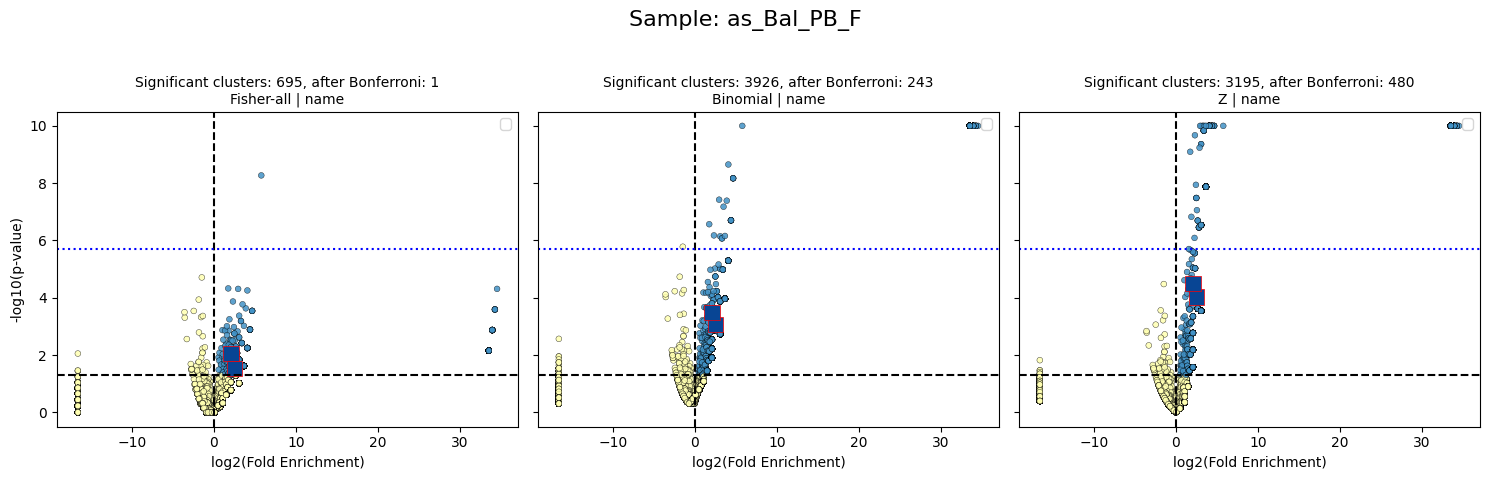

     cluster_id    pvalue  fold_enrichment  vdjdb
960         960  0.018458        22.802893   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id    pvalue  fold_enrichment  vdjdb
960         960  0.000105        22.802893   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
960         960  1.067633e-10        22.802893   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


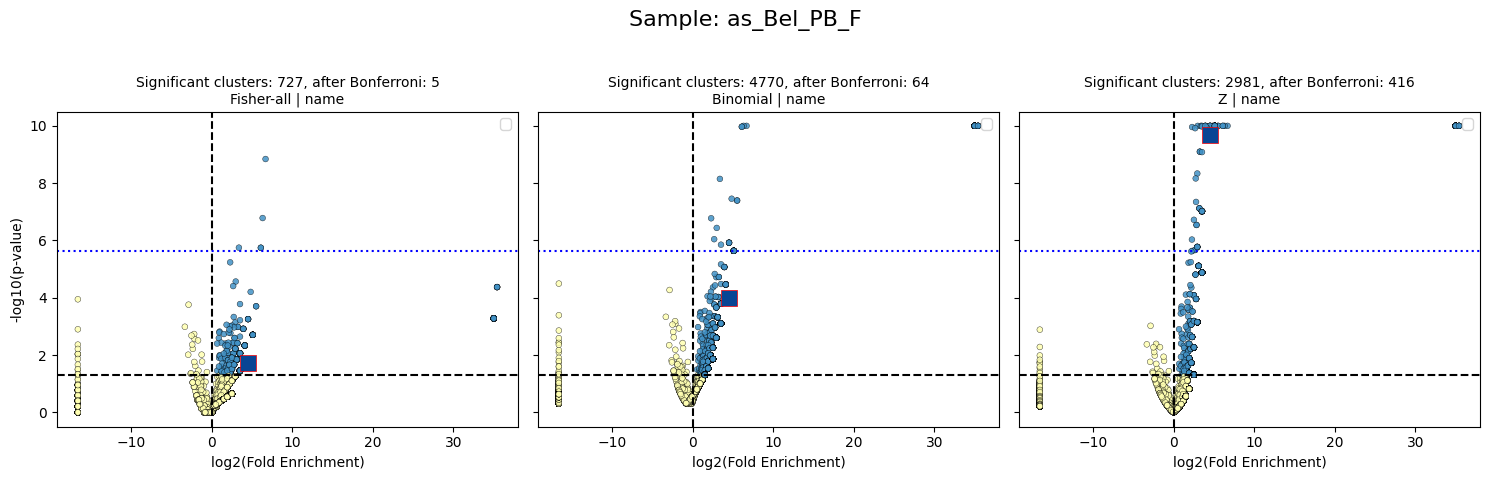

     cluster_id    pvalue  fold_enrichment  vdjdb
427         427  0.001764         9.918255   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
427         427  8.173318e-07         9.918255   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
427         427  6.772360e-14         9.918255   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


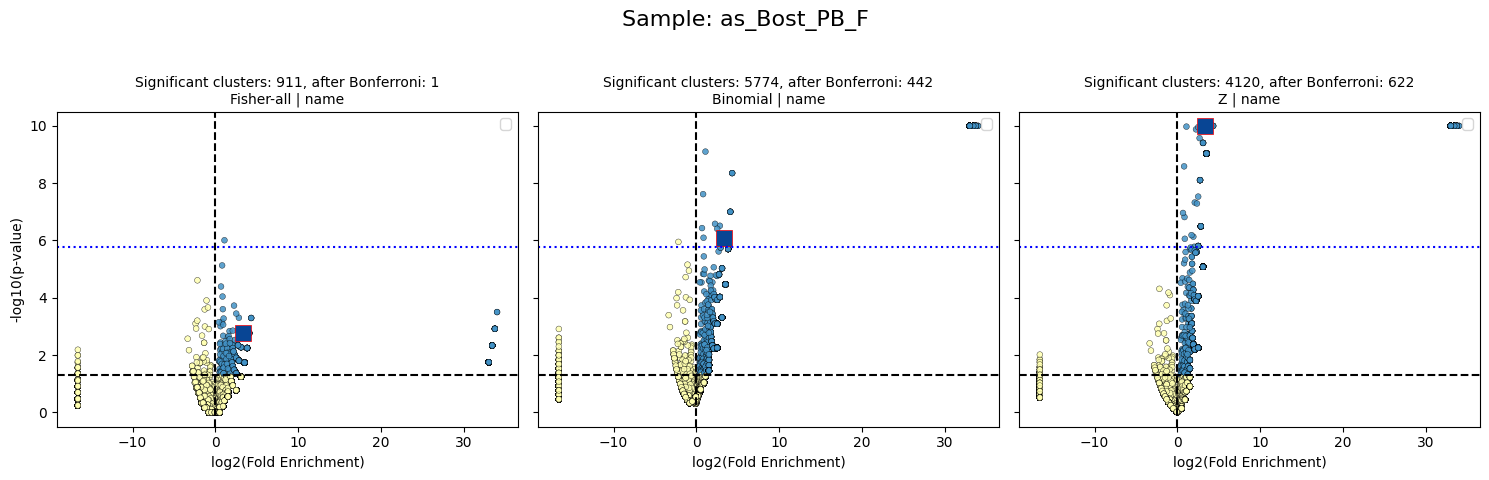

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


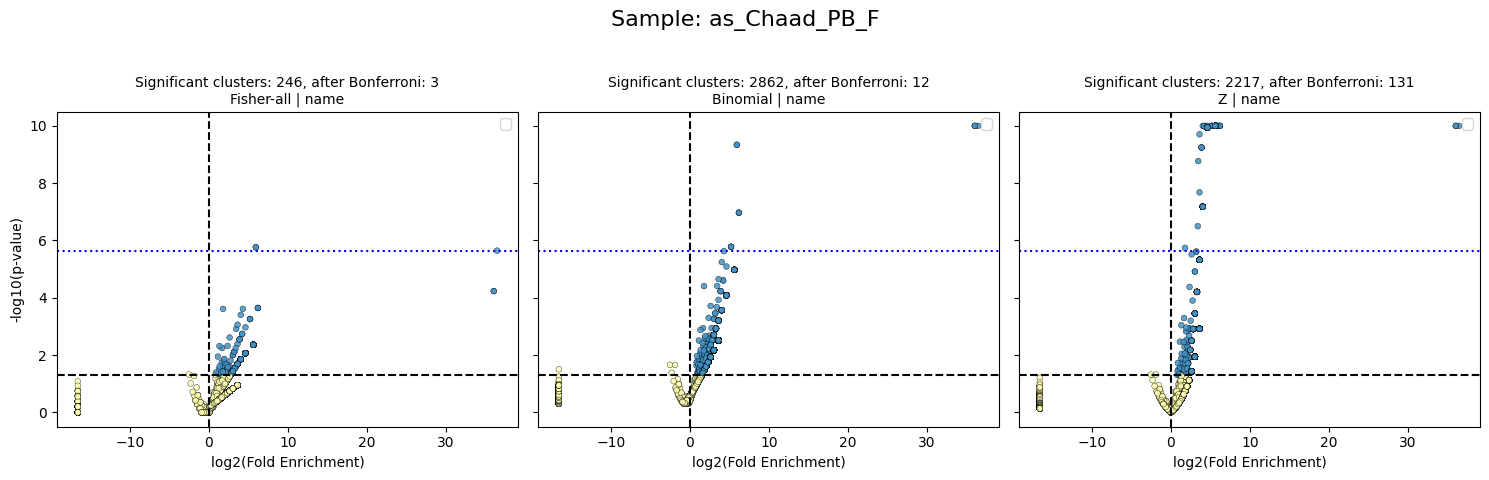

      cluster_id    pvalue  fold_enrichment  vdjdb
5307        5307  0.016305     7.193772e+09   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id  pvalue  fold_enrichment  vdjdb
5307        5307     0.0     7.193772e+09   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id  pvalue  fold_enrichment  vdjdb
5307        5307     0.0     7.193772e+09   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


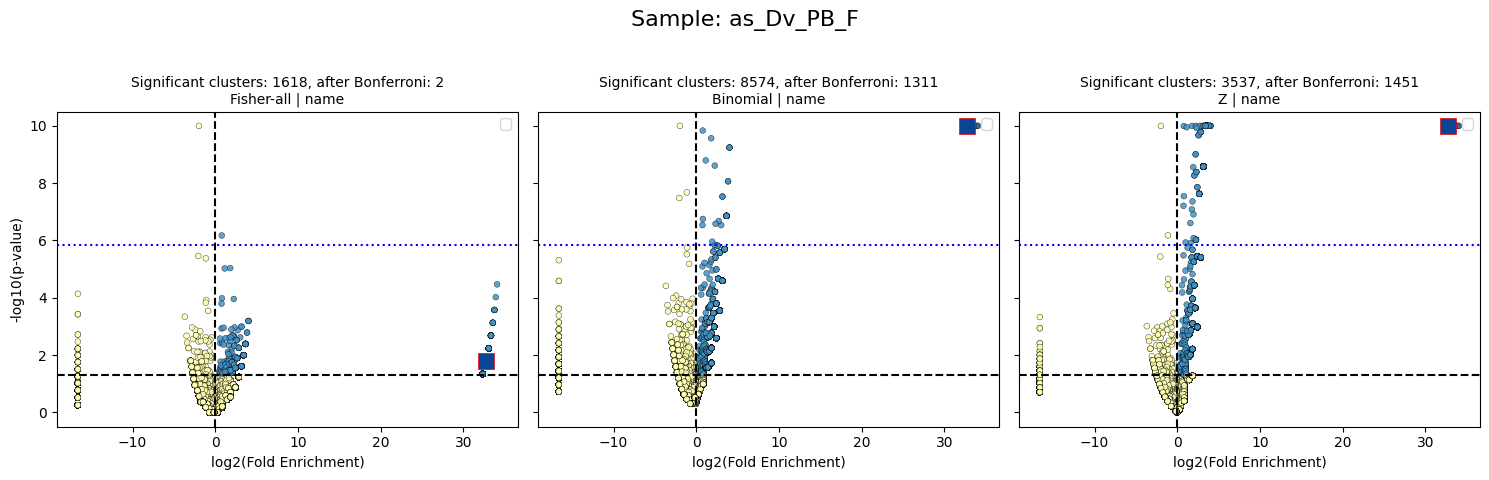

    cluster_id    pvalue  fold_enrichment  vdjdb
48          48  0.001945        12.596681   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


    cluster_id    pvalue  fold_enrichment  vdjdb
48          48  0.000004        12.596681   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


    cluster_id        pvalue  fold_enrichment  vdjdb
48          48  2.748912e-13        12.596681   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


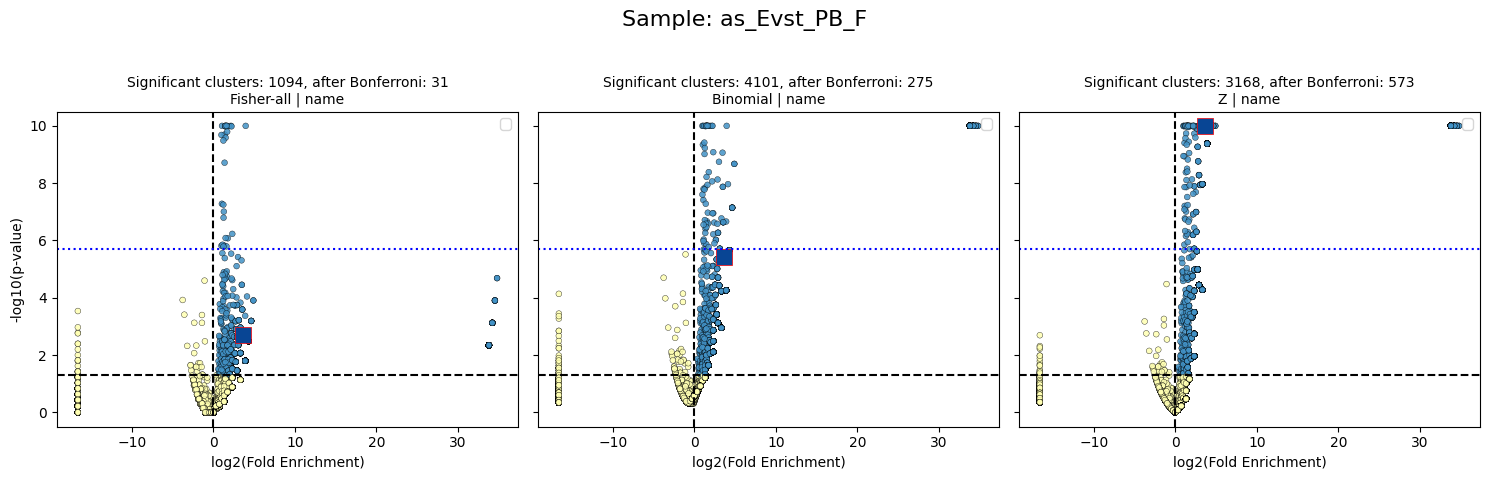

     cluster_id    pvalue  fold_enrichment  vdjdb
44           44  0.002446     1.398621e+10   True
339         339  0.002446     1.398621e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id  pvalue  fold_enrichment  vdjdb
44           44     0.0     1.398621e+10   True
339         339     0.0     1.398621e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id  pvalue  fold_enrichment  vdjdb
44           44     0.0     1.398621e+10   True
339         339     0.0     1.398621e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


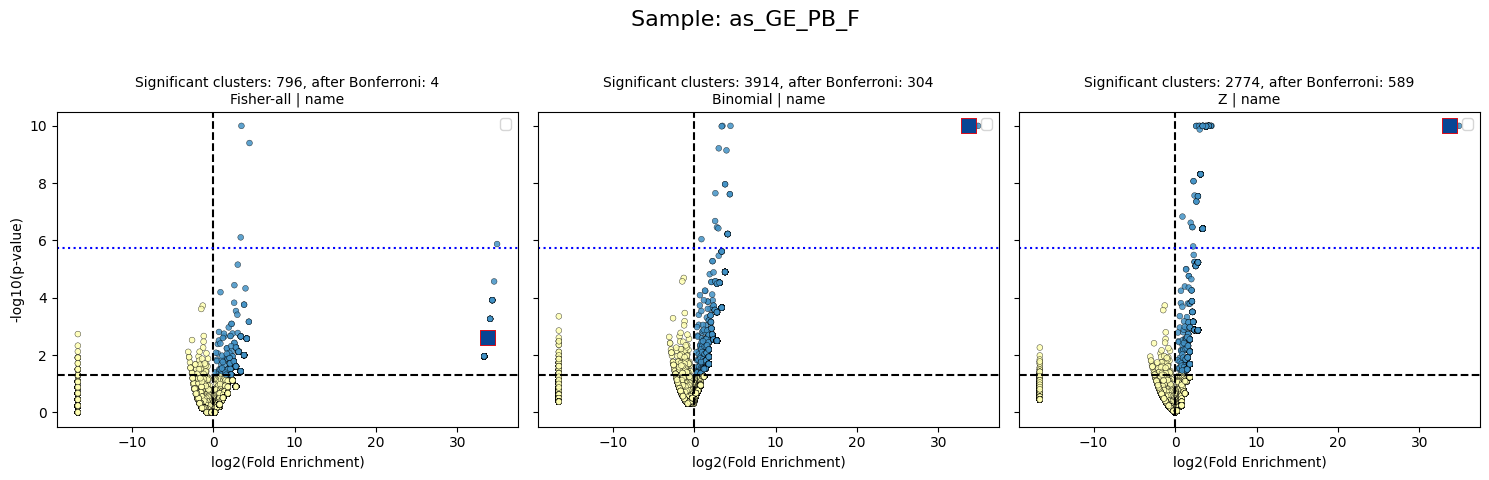

      cluster_id    pvalue  fold_enrichment  vdjdb
2322        2322  0.023353           2.8971   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id    pvalue  fold_enrichment  vdjdb
2322        2322  0.003474           2.8971   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id    pvalue  fold_enrichment  vdjdb
2322        2322  0.003189           2.8971   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


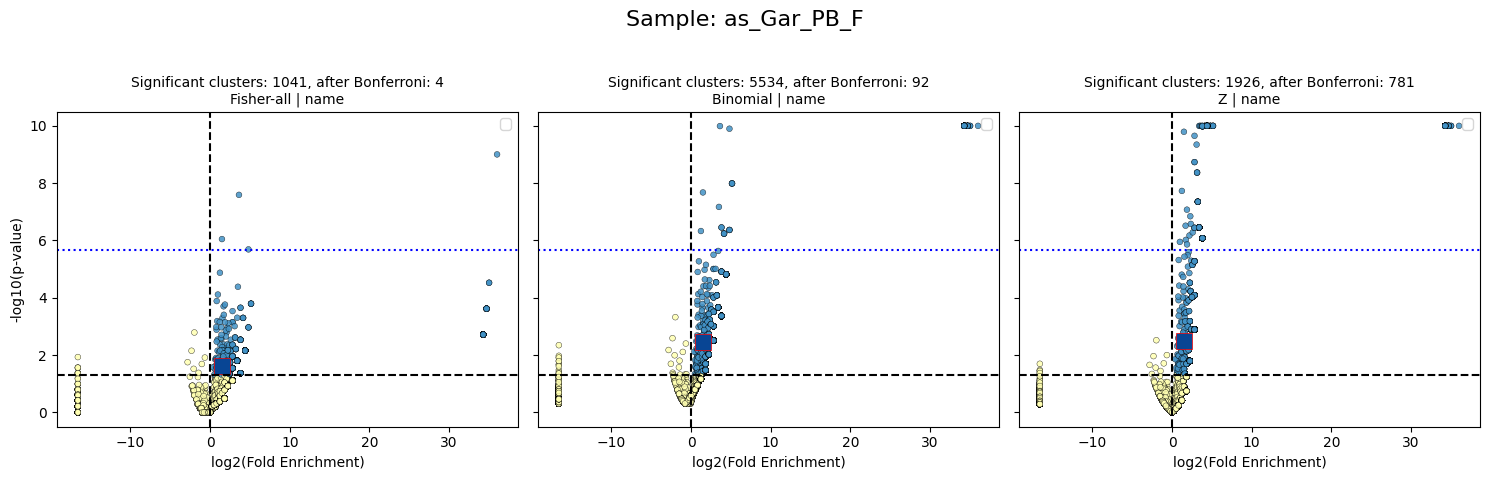

     cluster_id    pvalue  fold_enrichment  vdjdb
593         593  0.006575        21.621074   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id    pvalue  fold_enrichment  vdjdb
593         593  0.000014        21.621074   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
593         593  1.576517e-14        21.621074   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


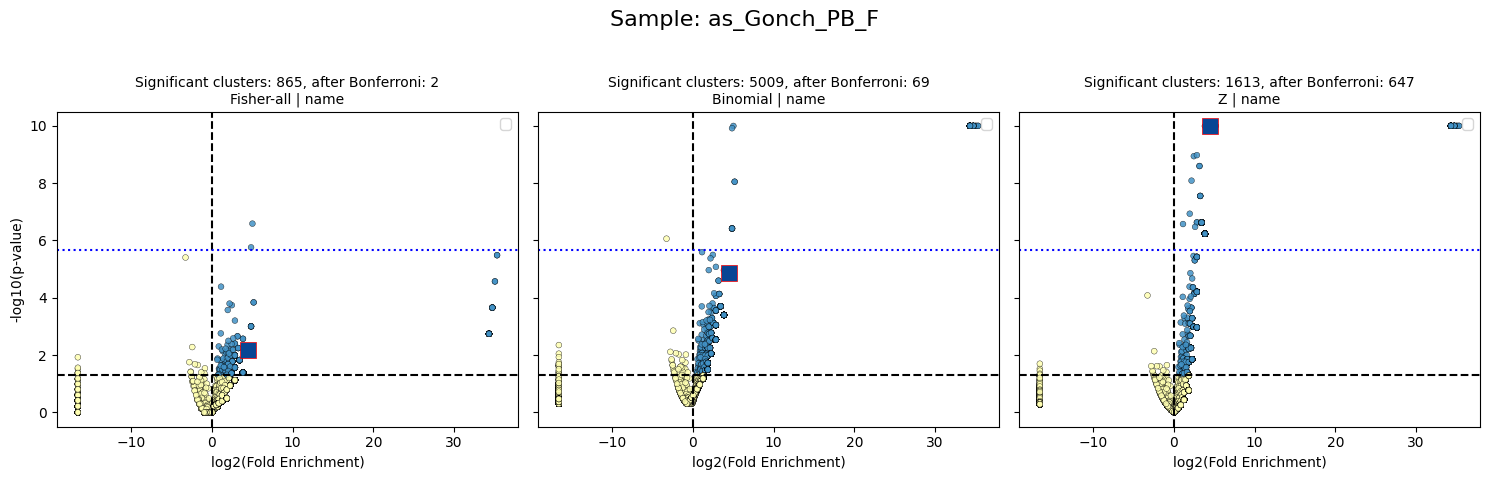

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


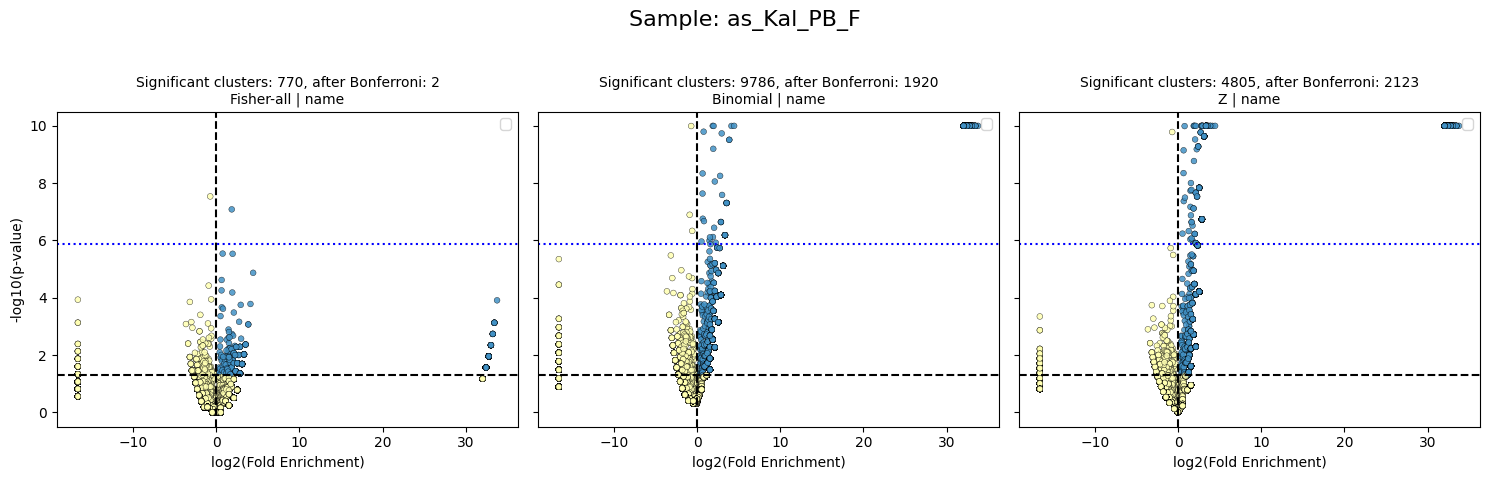

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


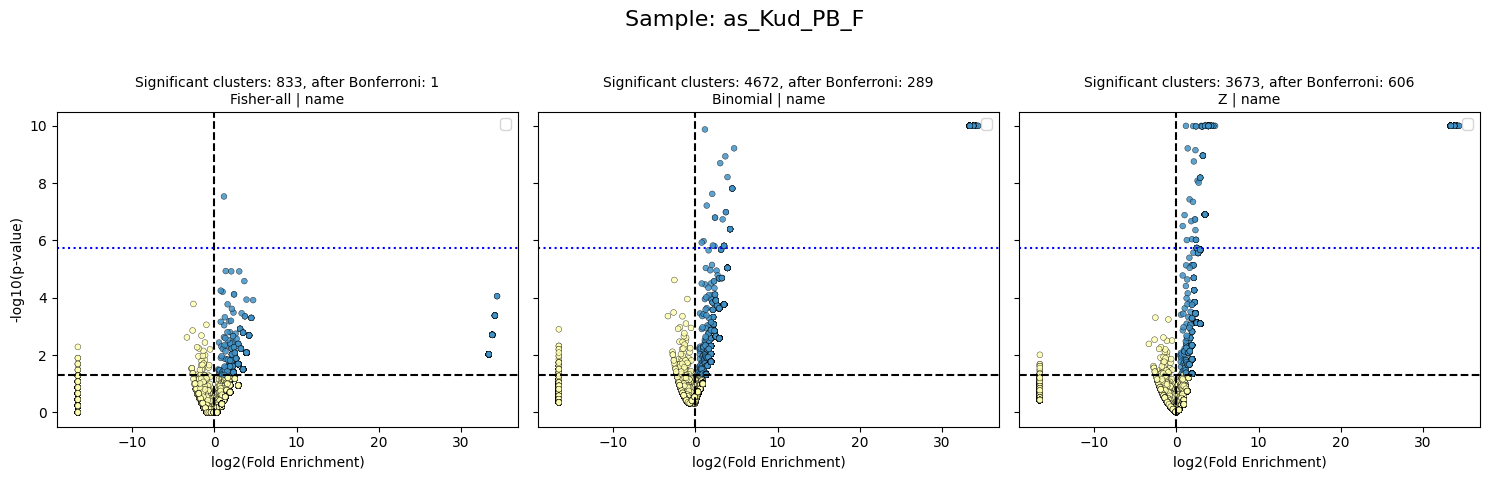

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


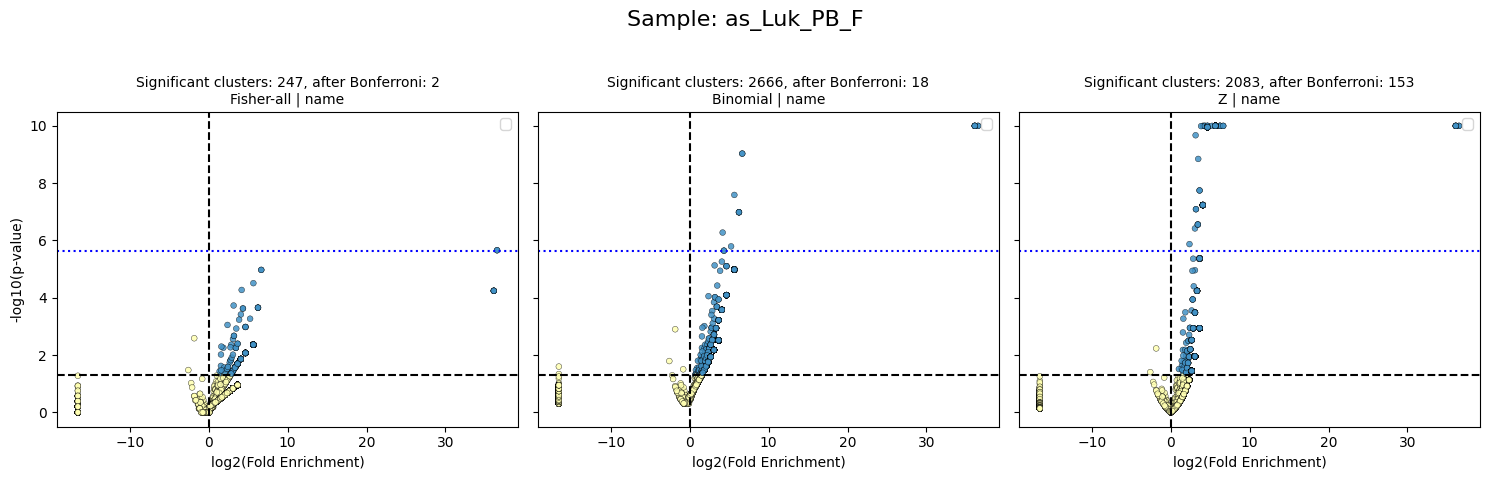

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


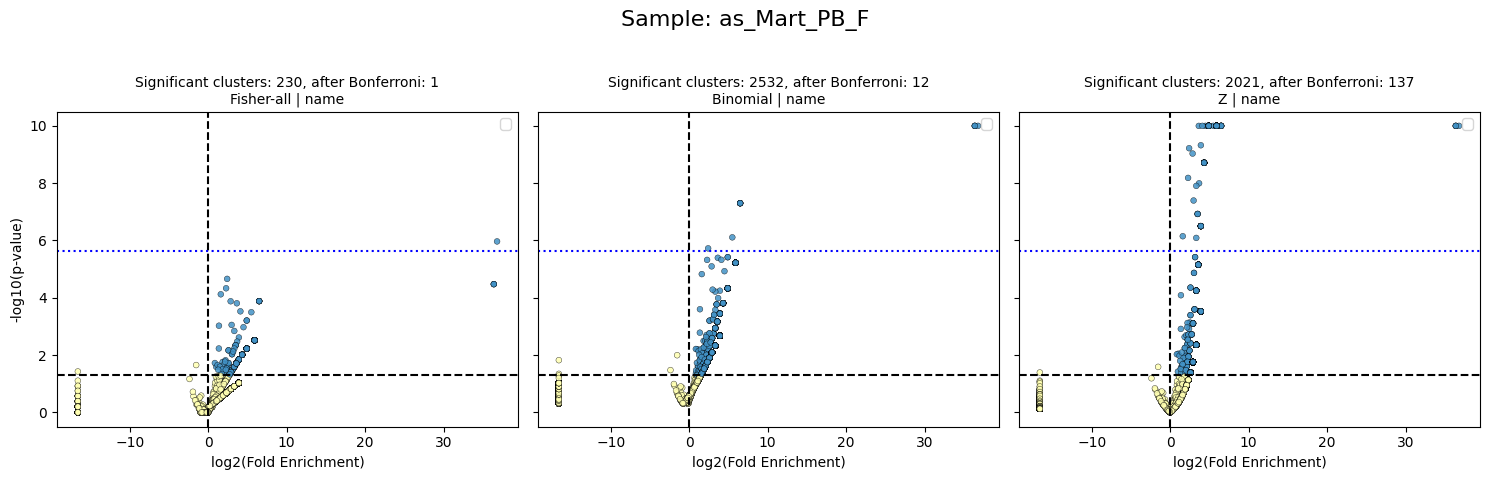

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


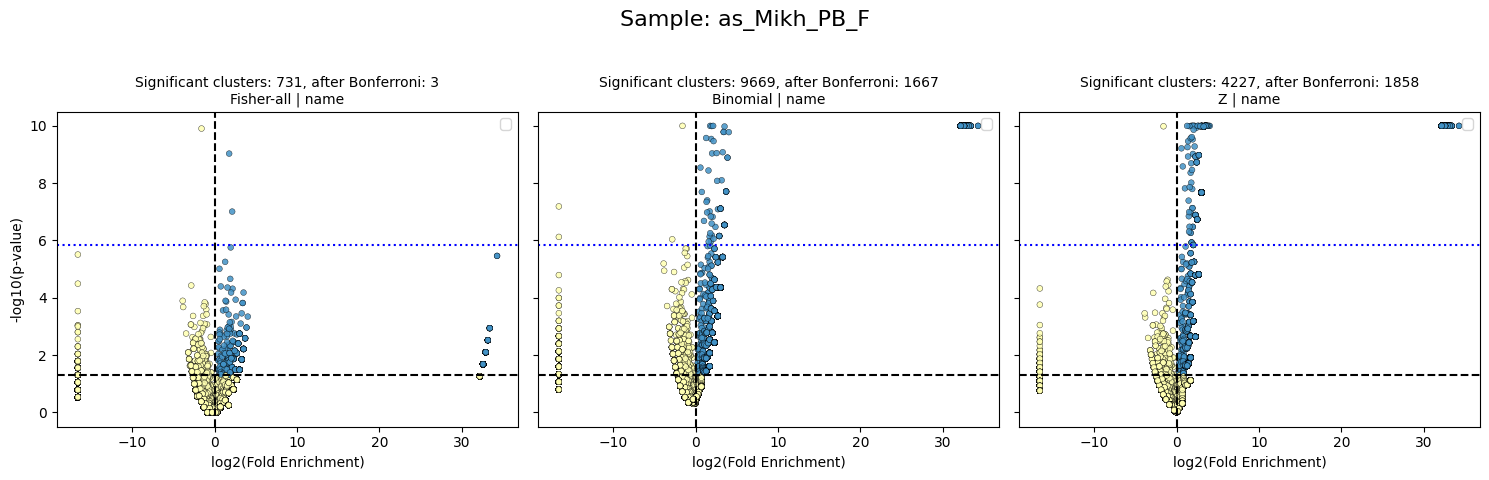

     cluster_id    pvalue  fold_enrichment  vdjdb
247         247  0.000007     2.473730e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id  pvalue  fold_enrichment  vdjdb
247         247     0.0     2.473730e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id  pvalue  fold_enrichment  vdjdb
247         247     0.0     2.473730e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


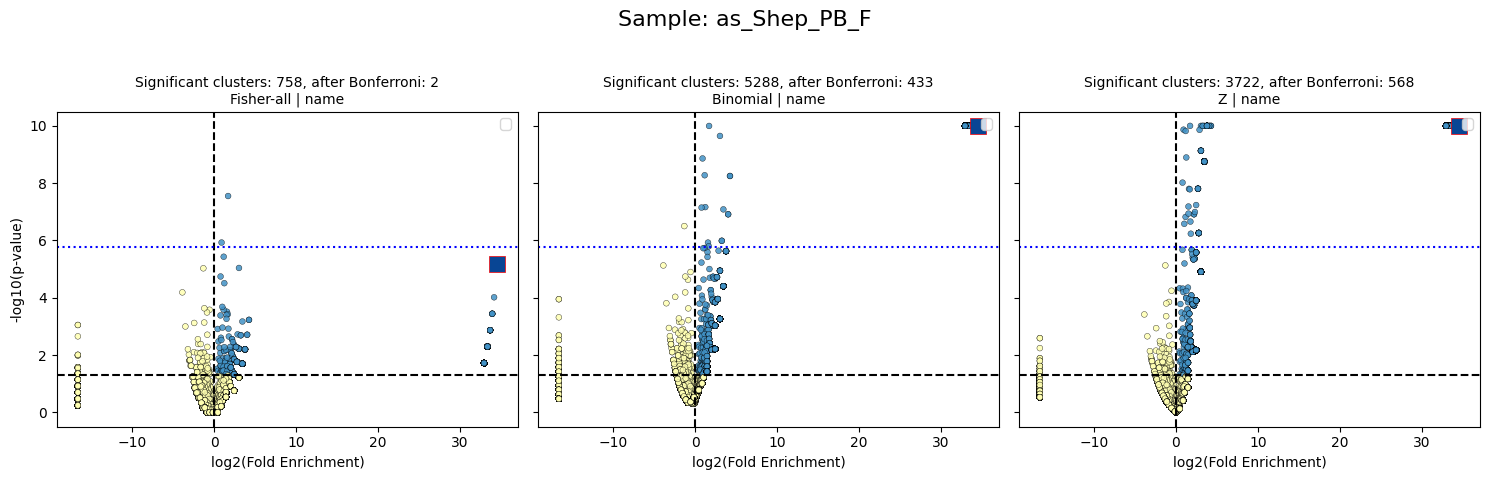

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


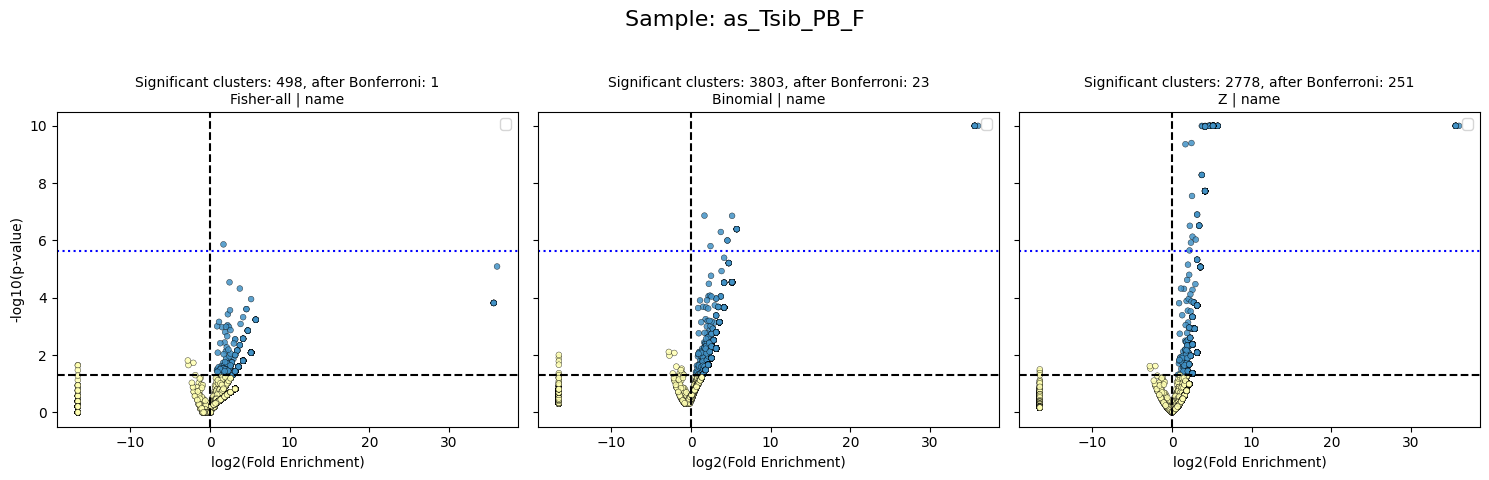

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


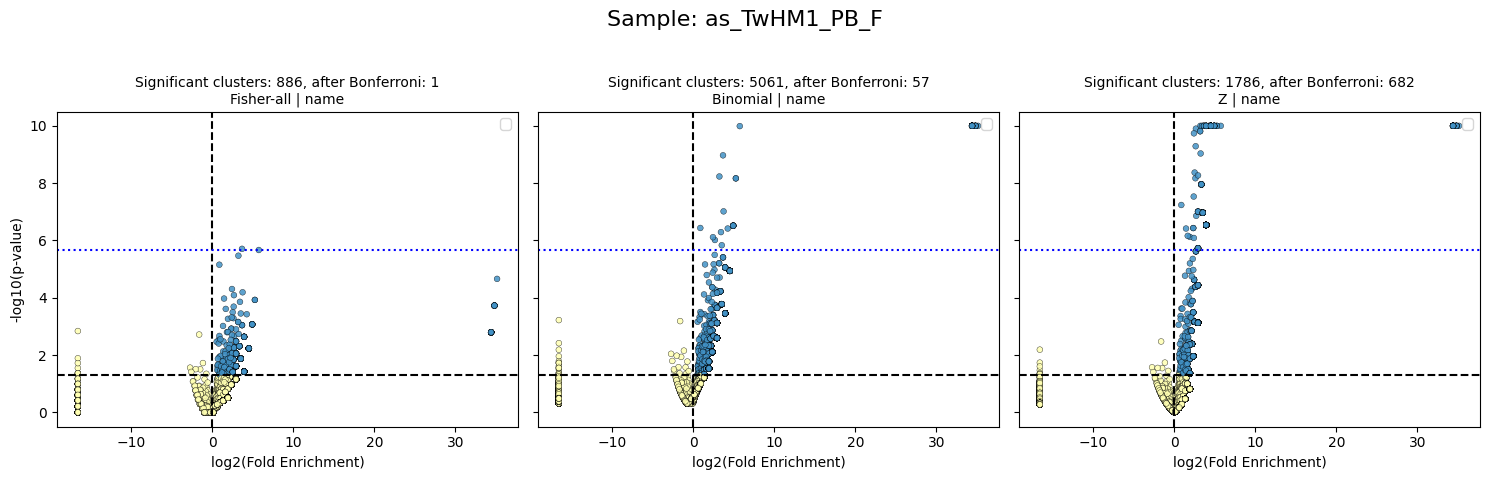

      cluster_id    pvalue  fold_enrichment  vdjdb
4500        4500  0.048208         2.920023   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id    pvalue  fold_enrichment  vdjdb
4500        4500  0.005229         2.920023   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


      cluster_id    pvalue  fold_enrichment  vdjdb
4500        4500  0.005918         2.920023   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


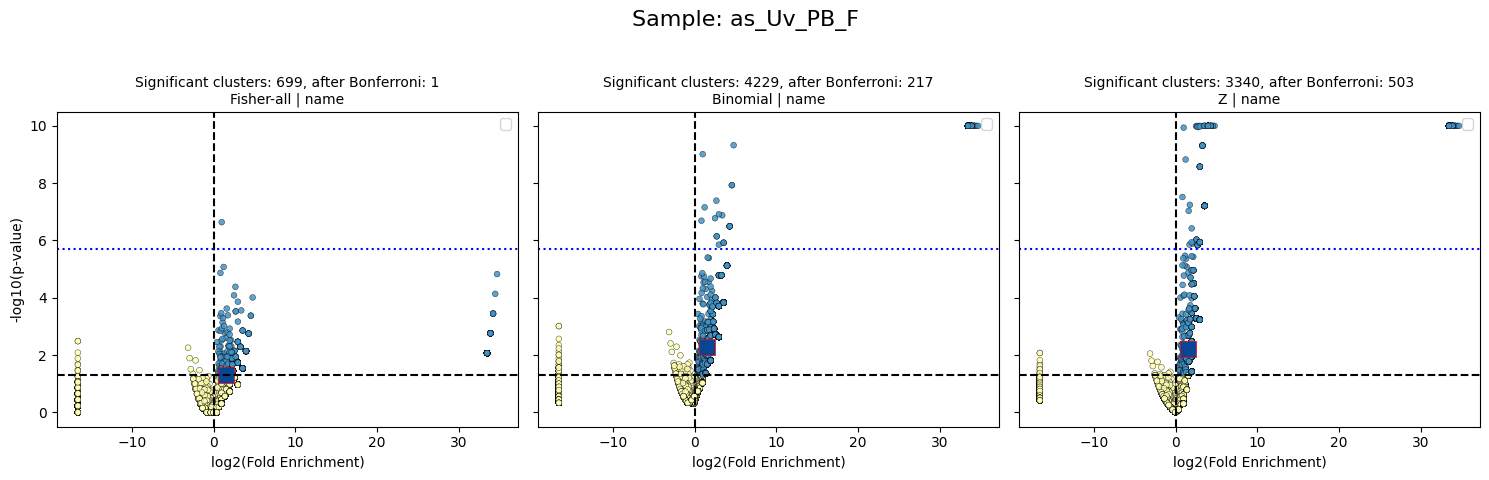

     cluster_id        pvalue  fold_enrichment  vdjdb
139         139  4.017503e-07     5.740585e+01   True
218         218  4.122158e-02     1.435146e+01   True
278         278  1.829829e-03     2.152719e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
139         139  4.818135e-14     5.740585e+01   True
218         218  4.064506e-04     1.435146e+01   True
278         278  0.000000e+00     2.152719e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
139         139  0.000000e+00     5.740585e+01   True
218         218  6.221745e-07     1.435146e+01   True
278         278  0.000000e+00     2.152719e+10   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


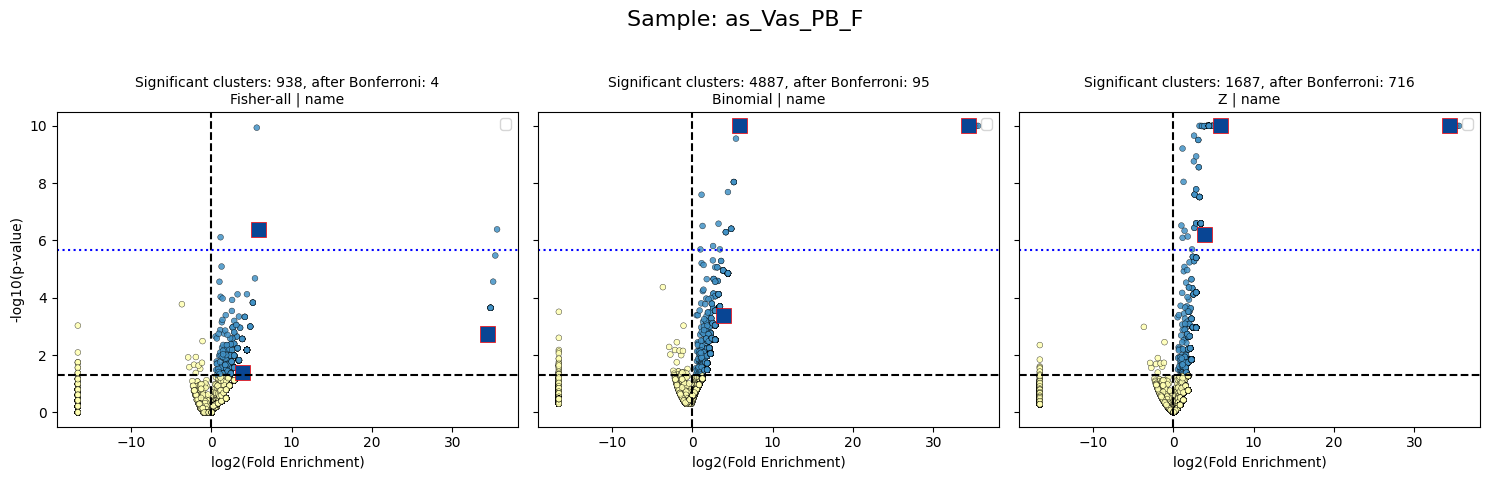

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


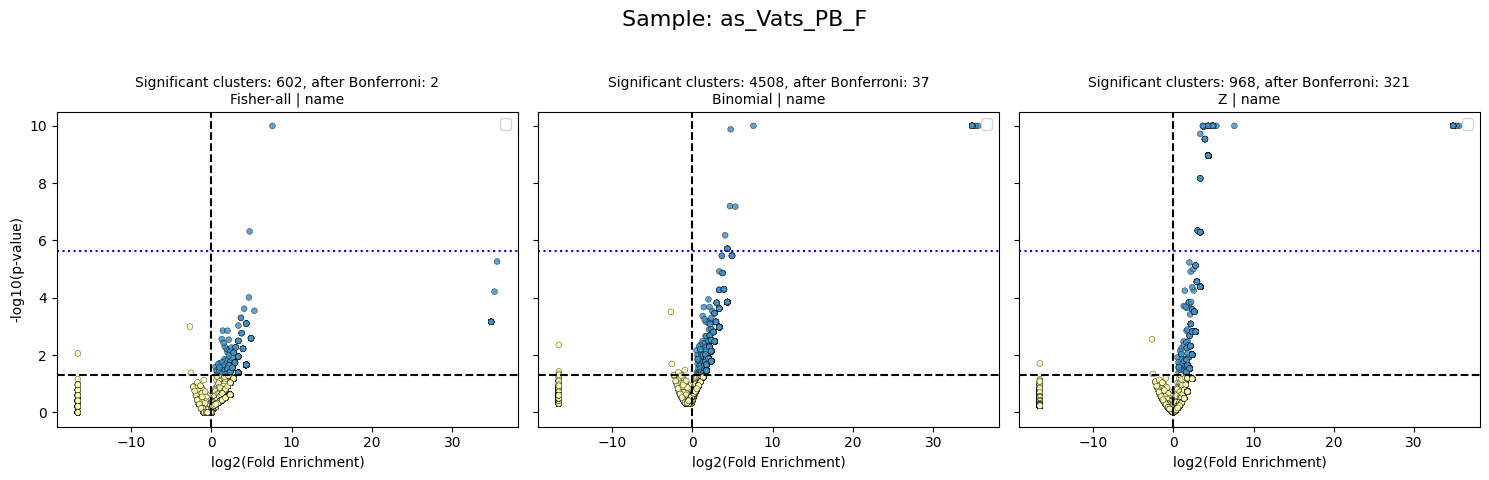

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


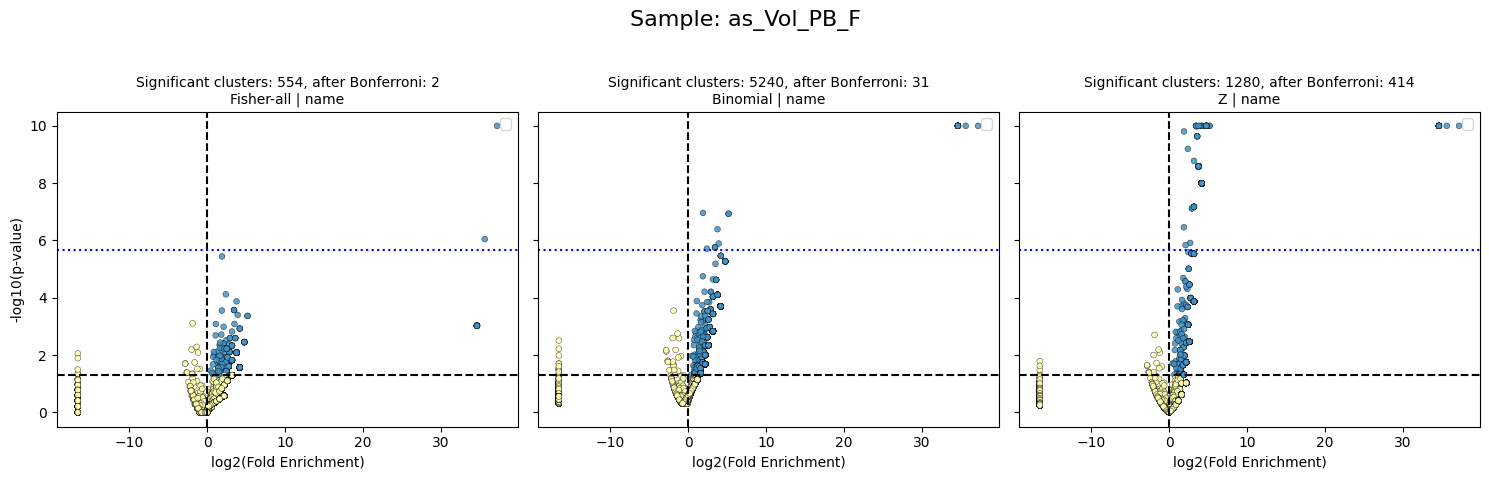

     cluster_id    pvalue  fold_enrichment  vdjdb
106         106  0.000687        17.861939   True
409         409  0.026660         4.121986   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id    pvalue  fold_enrichment  vdjdb
106         106  0.000004        17.861939   True
409         409  0.003226         4.121986   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


     cluster_id        pvalue  fold_enrichment  vdjdb
106         106  1.554312e-15        17.861939   True
409         409  2.101737e-03         4.121986   True


/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


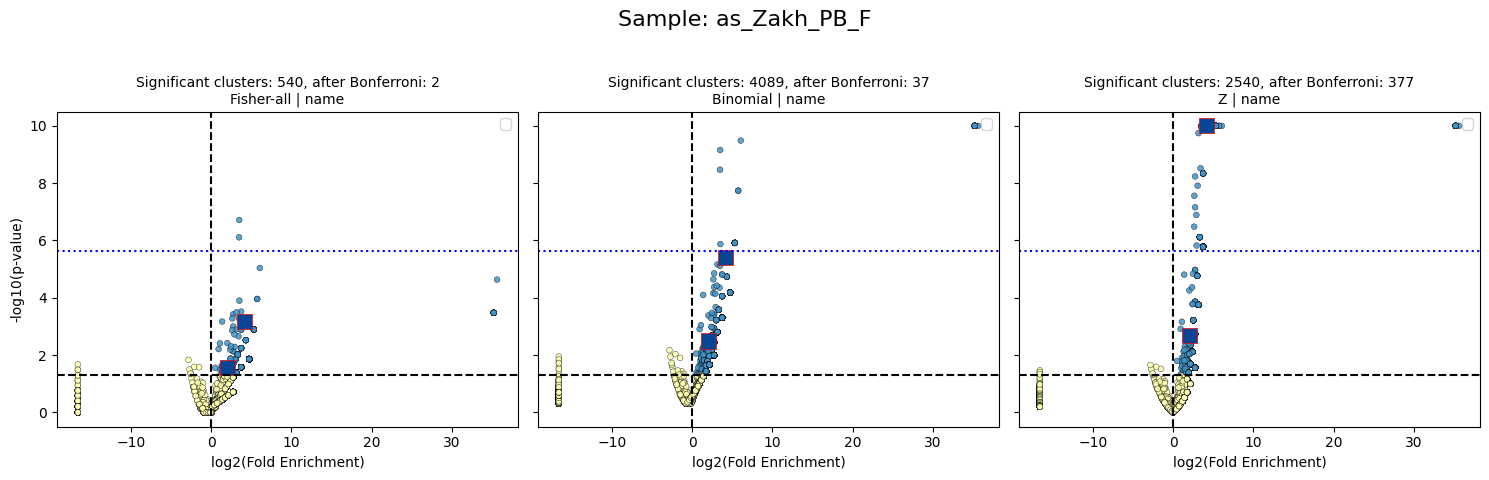

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


/scratch/ipykernel_3630097/1891291844.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/scratch/ipykernel_3630097/1891291844.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


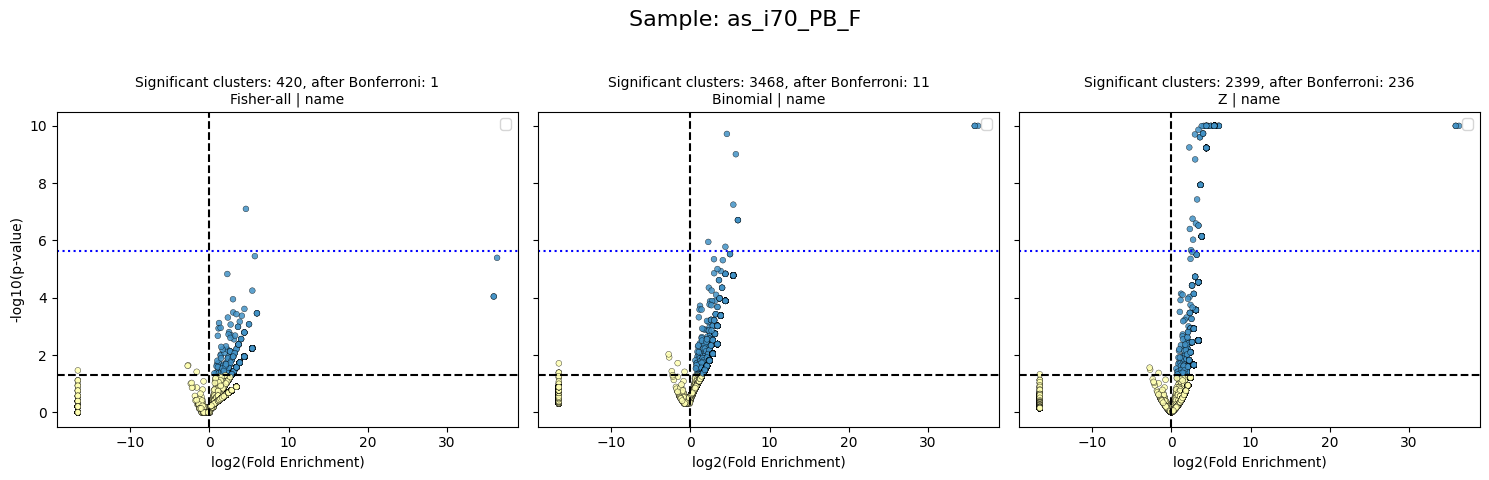

In [31]:
import matplotlib.pyplot as plt

methods = ['fisher-all', 'binomial', 'z']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

for s in samples:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            ax = axes[j]
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            print(res_df[res_df.vdjdb])
            plot_volcano(res_df, ax=ax, fold_threshold=1)

            # Не перезаписываем, а дописываем
            old_title = ax.get_title()
            ax.set_title(f"{old_title}\n{method.capitalize()} | {sampling_title}", fontsize=10)
            
    plt.suptitle(f'Sample: {s}', fontsize=16)
    plt.savefig(f'cluster_volcanos/{s}.png', dpi=300)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [32]:
res_df

,cluster_id,pvalue,fold_enrichment,vdjdb
0,0,0.000000,31.965067,False
1,1,0.114088,4.262009,False
2,2,0.000000,24.354337,False
3,3,0.022021,7.103348,False
4,4,0.022021,7.103348,False
...,...,...,...,...
21153,21153,0.707508,0.000000,False
21154,21154,0.707508,0.000000,False
21155,21155,0.707508,0.000000,False
21156,21156,0.707508,0.000000,False


In [33]:
test = compute_enrichment_pvalues(
                sample_to_data['as_Abd_PB_F'][0],
                sample_overall=sample_to_data['as_Abd_PB_F'][2],
                background_overall=sample_to_data['as_Abd_PB_F'][1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
test[test.pvalue < 0.05 / len(test)]

,cluster_id,pvalue,fold_enrichment
8,8,0.000000e+00,2.515691e+10
10,10,5.798229e-11,1.048204e+01
11,11,0.000000e+00,2.515691e+10
12,12,5.143854e-08,1.677127e+01
13,13,0.000000e+00,3.354254e+10
...,...,...,...
22666,22666,5.143854e-08,1.677127e+01
22719,22719,5.143854e-08,1.677127e+01
22725,22725,5.143854e-08,1.677127e+01
22794,22794,5.143854e-08,1.677127e+01


In [34]:
from tqdm import tqdm
methods = ['z']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

all_info = []
for s in tqdm(samples):
    print(f'threshold for {s} is {0.05 / len(res_df)}')
    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df[(res_df.pvalue < 0.05 / len(res_df)) & (res_df.fold_enrichment > 0)]
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            res_df['sample'] = s
            all_info.append(res_df)

  0%|          | 0/27 [00:00<?, ?it/s]

threshold for as_Abd_PB_F is 2.3631723225257587e-06


  4%|▎         | 1/27 [00:02<01:17,  2.97s/it]

threshold for as_Abr_PB_F is 8.116883116883117e-05


  7%|▋         | 2/27 [00:05<01:11,  2.86s/it]

...

 93%|█████████▎| 25/27 [01:20<00:06,  3.04s/it]

threshold for as_Zakh_PB_F is 0.00012077294685990339


 96%|█████████▋| 26/27 [01:23<00:02,  2.96s/it]

threshold for as_i70_PB_F is 0.00013262599469496023


100%|██████████| 27/27 [01:26<00:00,  3.20s/it]


In [35]:
joint = pd.concat(all_info)

In [36]:
joint

,cluster_id,pvalue,fold_enrichment,vdjdb,sample
0,8,0.000000e+00,2.515691e+10,False,as_Abd_PB_F
1,10,5.798229e-11,1.048204e+01,False,as_Abd_PB_F
2,11,0.000000e+00,2.515691e+10,False,as_Abd_PB_F
3,12,5.143854e-08,1.677127e+01,False,as_Abd_PB_F
4,13,0.000000e+00,3.354254e+10,False,as_Abd_PB_F
...,...,...,...,...,...
231,18983,0.000000e+00,4.262009e+01,False,as_i70_PB_F
232,19592,0.000000e+00,4.262009e+01,False,as_i70_PB_F
233,19630,0.000000e+00,4.262009e+01,False,as_i70_PB_F
234,19851,4.906737e-10,2.131004e+01,False,as_i70_PB_F


In [37]:
joint[joint.vdjdb].sort_values(by='sample')

,cluster_id,pvalue,fold_enrichment,vdjdb,sample
132,960,1.067633e-10,2.280289e+01,True,as_Bel_PB_F
42,427,6.772360e-14,9.918255e+00,True,as_Bost_PB_F
440,5307,0.000000e+00,7.193772e+09,True,as_Dv_PB_F
13,48,2.748912e-13,1.259668e+01,True,as_Evst_PB_F
12,44,0.000000e+00,1.398621e+10,True,as_GE_PB_F
49,339,0.000000e+00,1.398621e+10,True,as_GE_PB_F
83,593,1.576517e-14,2.162107e+01,True,as_Gonch_PB_F
28,247,0.000000e+00,2.473730e+10,True,as_Shep_PB_F
25,139,0.000000e+00,5.740585e+01,True,as_Vas_PB_F
45,218,6.221745e-07,1.435146e+01,True,as_Vas_PB_F


In [38]:
joint[joint['sample'] == 'as_Abd_PB_F'].cluster_id

0          8
1         10
2         11
3         12
4         13
       ...  
611    22666
612    22719
613    22725
614    22794
615    22795
Name: cluster_id, Length: 616, dtype: int64

In [39]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient).drop(columns=['enrichment_pvalue'])
    # t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [40]:
data = pd.concat(all_clonotypes_enriched)#.drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F
...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F


In [41]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [42]:
data[data.vdjdb][['sample_name']].drop_duplicates()

,sample_name
139,as_Bel_PB_F
113,as_Bost_PB_F
1001,as_Dv_PB_F
29,as_Evst_PB_F
17,as_GE_PB_F
164,as_Gonch_PB_F
69,as_Shep_PB_F
60,as_Vas_PB_F
30,as_Zakh_PB_F


In [43]:
data.to_csv('as_found_clonotypes_b27pos.csv', index=False)

In [44]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [45]:
import networkx as nx
from collections import defaultdict

In [46]:
df = data

In [47]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [48]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4
...,...,...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495


In [49]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [50]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False
...,...,...,...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827,False
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495,False


In [51]:
df.cluster_id.value_counts()

cluster_id
as_Evst_PB_F_c140     600
as_Mikh_PB_F_c515     482
as_Evst_PB_F_c24      471
as_TwHM1_PB_F_c296    425
as_Evst_PB_F_c115     370
                     ... 
as_Dv_PB_F_c19470       3
as_Kud_PB_F_c10400      3
as_Dv_PB_F_c19497       3
as_Kud_PB_F_c10321      3
as_Kud_PB_F_c9703       3
Name: count, Length: 13906, dtype: int64

In [52]:
df.merged_cluster_id.value_counts()

merged_cluster_id
157     2420
4488    2027
1084    1242
3130    1069
1234    1043
        ... 
5412       3
897        3
5426       3
5425       3
5473       3
Name: count, Length: 10619, dtype: int64

In [53]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,1,1
1,1,1
2,1,1
3,1,1
4,18,1
...,...,...
10614,1,1
10615,1,1
10616,1,1


In [54]:
df[df.merged_cluster_id == 10616]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
1226,s_39569,as_i70_PB_F_c3595,CASSLGVEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_i70_PB_F,False,10616,False
1227,s_39571,as_i70_PB_F_c3595,CASSLGLEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_i70_PB_F,False,10616,False
3084,b_338268,as_i70_PB_F_c3595,CASSLGVEQYF,TRBV5-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,10616,False
4080,b_483307,as_i70_PB_F_c3595,CASSLGVEQYF,TRBV5-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,10616,False
4463,b_539614,as_i70_PB_F_c3595,CASSVGLEQYF,TRBV5-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,10616,False


In [55]:
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
source_counts

source,merged_cluster_id,background,sample
0,0,0,3
1,1,4,5
2,2,0,3
3,3,1,2
4,4,322,376
...,...,...,...
10614,10614,1,2
10615,10615,1,2
10616,10616,3,2
10617,10617,2,2


In [56]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

,sample_name,as_pattern
merged_cluster_id,,
0,1,False
1,1,False
2,1,False
3,1,False
4,18,False
...,...,...
10614,1,False
10615,1,False
10616,1,False


In [57]:
from mir.basic.pgen import OlgaModel

In [58]:
olga = OlgaModel()

In [59]:
olga.compute_pgen_cdr3aa('CASSPPSGSYEQYF')

2.0855611266511384e-07

In [60]:
df['pgen'] = df.cdr3aa_beta.apply(olga.compute_pgen_cdr3aa)

In [61]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827,False,8.020229e-07
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.476498e-06
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.801972e-06
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495,False,1.065633e-08


In [62]:
# Считаем общий размер кластера
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")

# Считаем количество пациентов и наличие паттерна
n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'as_pattern': 'any', 
    'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})

# Считаем количество элементов из каждого источника (source)
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()

# Объединяем таблицы
summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")

# Считаем доли элементов из каждого источника
summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']

# Сортировка
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [63]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
1084,1084,1242,22,False,6.534613e-07,693,549,0.442029,0.557971
267,267,681,20,False,5.824201e-07,384,297,0.436123,0.563877
4,4,698,18,False,4.251389e-07,322,376,0.538682,0.461318
609,609,765,17,False,1.981194e-07,304,461,0.602614,0.397386
241,241,592,17,False,2.214852e-07,291,301,0.508446,0.491554
...,...,...,...,...,...,...,...,...,...
10610,10610,3,1,False,6.506542e-10,1,2,0.666667,0.333333
10613,10613,3,1,False,2.901185e-07,1,2,0.666667,0.333333
10614,10614,3,1,False,1.323308e-08,1,2,0.666667,0.333333
10615,10615,3,1,False,2.225843e-07,1,2,0.666667,0.333333


In [64]:
#summary[summary.n_patients > 3].sort_values(by=['pgen',  'sample_fraction', 'n_patients'], ascending=True).head(50).reset_index(drop=True)

In [65]:
df[df.merged_cluster_id == 2276].sort_values(by='cdr3aa_beta')

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
481,s_15280,as_GE_PB_F_c279,CASSDASGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_GE_PB_F,False,2276,False,1.674822e-09
763,s_31756,as_GE_PB_F_c279,CASSDSSGGADEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_GE_PB_F,False,2276,False,1.421378e-09
7007,b_334216,as_Uv_PB_F_c879,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,background,as_Uv_PB_F,False,2276,False,4.745136e-09
375,s_14512,as_Uv_PB_F_c879,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_Uv_PB_F,False,2276,False,4.745136e-09
6376,b_334216,as_GE_PB_F_c279,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,background,as_GE_PB_F,False,2276,False,4.745136e-09
768,s_31771,as_GE_PB_F_c279,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_GE_PB_F,False,2276,False,4.745136e-09
95,s_1962,as_GE_PB_F_c279,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_GE_PB_F,False,2276,False,4.745136e-09
44,s_385,as_Bel_PB_F_c71,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_Bel_PB_F,False,2276,False,4.745136e-09
207,s_2989,as_Evst_PB_F_c32,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_Evst_PB_F,False,2276,False,4.745136e-09
21,s_241,as_Evst_PB_F_c32,CASSDSSGGANEQFF,TRBV6-4*01,TRBJ2-1*01,sample,as_Evst_PB_F,False,2276,False,4.745136e-09


In [66]:
df[df.merged_cluster_id == 391].sort_values(by='cdr3aa_beta')

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
3550,s_399291,as_Kal_PB_F_c4304,CASSAGFSTDTQYF,TRBV12-4*01,TRBJ2-3*01,sample,as_Kal_PB_F,False,391,False,2.078210e-08
1375,s_77945,as_Gar_PB_F_c19201,CASSAGLAPDTQYF,TRBV7-3*01,TRBJ2-3*01,sample,as_Gar_PB_F,False,391,False,1.120464e-08
1327,s_105161,as_Kal_PB_F_c4304,CASSAGLATDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Kal_PB_F,False,391,False,5.002024e-08
3549,s_399177,as_Kal_PB_F_c4304,CASSAGLNTDTQYF,TRBV12-4*01,TRBJ2-3*01,sample,as_Kal_PB_F,False,391,False,1.227160e-08
675,s_40644,as_Kal_PB_F_c4304,CASSAGLSTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Kal_PB_F,False,391,False,7.412165e-08
3677,b_488237,as_Vats_PB_F_c2487,CASSAGLSTDTQYF,TRBV11-2*01,TRBJ2-3*01,background,as_Vats_PB_F,False,391,False,7.412165e-08
705,s_55484,as_Vats_PB_F_c2487,CASSAGTTTDTQYF,TRBV11-2*01,TRBJ2-3*01,sample,as_Vats_PB_F,False,391,False,1.944612e-08
9226,b_246078,as_Kal_PB_F_c4304,CASSAGVDTDTQYF,TRBV12-4*01,TRBJ2-3*01,background,as_Kal_PB_F,False,391,False,1.986148e-08
708,s_55562,as_Vats_PB_F_c2487,CASSAGVSTDTQYF,TRBV11-2*01,TRBJ2-3*01,sample,as_Vats_PB_F,False,391,False,9.316881e-08
1225,s_64791,as_Abd_PB_F_c3462,CASSDGLATDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,391,False,2.122989e-08


In [67]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
157,157,2420,11,False,2.863143e-08,1425,995,0.411157,0.588843
4488,4488,2027,3,False,2.904618e-08,1464,563,0.277750,0.722250
1084,1084,1242,22,False,6.534613e-07,693,549,0.442029,0.557971
3130,3130,1069,6,False,6.512370e-08,704,365,0.341441,0.658559
1234,1234,1043,6,False,1.460689e-08,719,324,0.310642,0.689358
4572,4572,950,3,False,3.844986e-08,551,399,0.420000,0.580000
628,628,832,7,False,3.172853e-08,530,302,0.362981,0.637019
609,609,765,17,False,1.981194e-07,304,461,0.602614,0.397386
4,4,698,18,False,4.251389e-07,322,376,0.538682,0.461318
267,267,681,20,False,5.824201e-07,384,297,0.436123,0.563877


In [68]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
2309,2309,59,9,True,4.064005e-09,11,48,0.813559,0.186441
4992,4992,7,2,True,3.462544e-09,0,7,1.000000,0.000000


In [69]:
import logomaker

In [70]:
def plot_logo(clonotypes):
    mat_df = logomaker.alignment_to_matrix(clonotypes)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

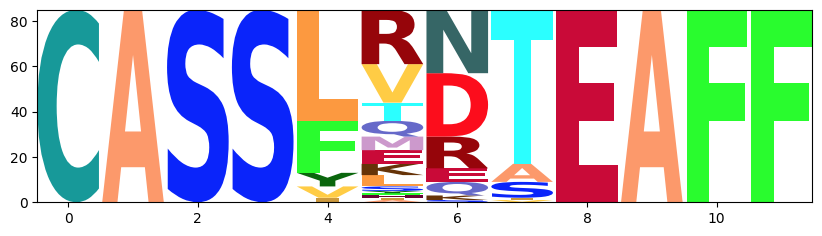

In [71]:
mat_df = logomaker.alignment_to_matrix(df[df.merged_cluster_id == 606].cdr3aa_beta)
logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)
# df[df.merged_cluster_id == 2309]

In [72]:
df[(df.merged_cluster_id == 2332) & ~(df.as_pattern)]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
207,s_4075,as_Bel_PB_F_c501,CASSLVTSGGQETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Bel_PB_F,False,2332,False,1.605005e-08
784,s_30165,as_Bel_PB_F_c501,CASSLVASGGQETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Bel_PB_F,False,2332,False,6.060993e-09
3149,b_190107,as_Bel_PB_F_c501,CASSLVTSGGQETQYF,TRBV5-1*01,TRBJ2-5*01,background,as_Bel_PB_F,False,2332,False,1.605005e-08


In [73]:
df[df.merged_cluster_id == 6223]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
834,s_69494,as_Gonch_PB_F_c3256,CASSLAIESYEQYF,TRBV7-2*01,TRBJ2-7*01,sample,as_Gonch_PB_F,False,6223,False,7.827669e-09
869,s_70395,as_Gonch_PB_F_c3256,CASSLSLDSYEQYF,TRBV7-2*01,TRBJ2-7*01,sample,as_Gonch_PB_F,False,6223,False,4.434233e-08
4069,b_312827,as_Gonch_PB_F_c3256,CASSLSVRTYEQYF,TRBV7-2*01,TRBJ2-7*01,background,as_Gonch_PB_F,False,6223,False,1.334017e-08


In [74]:
import logomaker

In [75]:
# for i in range(4):
#     seqs = dataset.clonotype_clustering[dataset.clonotype_clustering.cluster == i].cdr3aa
#     mat_df = logomaker.alignment_to_matrix(seqs)
#     logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

In [76]:
from importlib import reload

In [77]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [78]:
metadata = metadata.reset_index(drop=True)

In [79]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 27/27 [00:33<00:00,  1.23s/it]

33.60002684593201


In [80]:
dataset.pair_matcher = PairMatcher(clonotype_representation_method='cdr3aa,vj',
                                   clonotype_comparison_method='full',)

In [81]:
dataset.mismatch_max = 0

In [82]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [83]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827,False,8.020229e-07
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.476498e-06
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.801972e-06
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495,False,1.065633e-08


In [84]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [85]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
5,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
6,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
7,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
6575,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827,False,8.020229e-07
6580,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.476498e-06
6581,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.801972e-06
6605,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495,False,1.065633e-08


In [86]:
public_clonotypes= public_clonotypes.reset_index(drop=True)

In [87]:
public_clonotypes = list(public_clonotypes)

In [88]:
public_clonotypes[10]

ClonotypeRepresentation(cdr3aa='CAISEREGSYNEQFF', v='TRBV10-3*01', j='TRBJ2-1*01', cdr3nt=None)

In [89]:
public_clono_set = set(public_clonotypes)

In [90]:
len(public_clono_set)

57473

In [91]:
list(public_clono_set)[10]

ClonotypeRepresentation(cdr3aa='CASSRGTGELFF', v='TRBV11-3*01', j='TRBJ2-2*01', cdr3nt=None)

In [92]:
ClonotypeRepresentation(cdr3aa = dataset[0][0].cdr3aa, v=dataset[0][0].v.id, j = dataset[0][0].j.id)

ClonotypeRepresentation(cdr3aa='CSASSETGELFF', v='TRBV20-1*01', j='TRBJ2-2*01', cdr3nt=None)

In [93]:
ClonotypeRepresentation(cdr3aa='CSAKDRGRVTEAFF', v='TRBV20-1*01', j='TRBJ1-1*01') in public_clonotypes

True

In [94]:
clonotype_idx_to_patients = defaultdict(set)
for patient in dataset:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients[i].add(patient)

In [95]:
metadata_h =metadata_h.reset_index(drop=True)

In [96]:
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [97]:
#metadata_h = metadata_h[metadata_h.b27 == 'pos'].reset_index(drop=True)

In [98]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 33/33 [00:48<00:00,  1.46s/it]


49.32745027542114


In [99]:
clonotype_idx_to_patients_h = defaultdict(set)
for patient in dataset_h:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients_h[i].add(patient)

In [100]:
df = df.reset_index(drop=True)

In [101]:
def get_cluster_usage(cluster_idx):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients[clono_idx])
        # print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients[clono_idx]])
    return len(all_patients)

In [102]:
def get_cluster_usage_h(cluster_idx, print_info=False):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients_h[clono_idx])
        if print_info:
            print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients_h[clono_idx]])
    return len(all_patients)

In [103]:
get_cluster_usage_h(2309, print_info=True)

11518 []
11649 []
13165 ['YB14_pre0', 'hd_Zbot_PB_F']
13251 []
13259 []
13294 []
13330 ['p556']
13886 ['p1004']
13888 []
13912 []
16201 ['p1004']
16203 ['p1004']
18509 []
19137 []
20749 []
20753 []
24545 []
24609 ['p556']
25261 []
25328 []
25329 []
30974 ['p1004']
30975 ['p1004']
36670 []
36676 []
36717 []
36875 []
43128 []
43356 []
43357 []
45377 ['YB14_pre0', 'hd_Zbot_PB_F']
62485 []
62486 []
62519 []
62530 []
62549 []
62570 []
62609 []
63586 []
63633 []
73677 []
73705 []
73722 []
73782 []
73869 []
73870 []
73872 []
74204 []
74315 []
74323 []
75834 ['p144852']
77125 ['YB14_pre0', 'hd_Zbot_PB_F']
80057 ['KB_0']
80064 []
80258 ['p556']
80259 []
81058 ['p1004']
81059 ['p1004']
81564 ['YB14_pre0', 'hd_Zbot_PB_F']


6

In [104]:
summary['as_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)

In [105]:
summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)

In [106]:
summary[summary.n_patients > 3].sort_values(by=['sample_fraction', 'n_patients'], ascending=False).head(60).reset_index(drop=True)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage
0,9,25,5,False,4.476789e-09,0,25,1.000000,0.000000,11,12
1,3382,20,4,False,1.649467e-07,0,20,1.000000,0.000000,6,5
2,2918,19,4,False,6.746954e-08,0,19,1.000000,0.000000,9,17
3,1641,18,4,False,4.732565e-08,0,18,1.000000,0.000000,12,16
4,1385,14,4,False,3.069090e-08,0,14,1.000000,0.000000,9,13
5,1160,13,4,False,3.013917e-07,0,13,1.000000,0.000000,13,16
6,324,19,4,False,1.280250e-07,1,18,0.947368,0.052632,13,14
7,4411,17,4,False,3.070759e-07,1,16,0.941176,0.058824,14,16
8,97,80,7,False,4.367828e-08,5,75,0.937500,0.062500,12,20
9,551,16,4,False,2.300562e-07,1,15,0.937500,0.062500,5,11


In [107]:
from scipy.stats import fisher_exact

In [108]:
total_as = 27
total_h = 33

# Результаты
p_values = []

# Пробегаем по строкам таблицы
for _, row in summary.iterrows():
    as_used = row["as_usage"]
    h_used = row["h_usage"]
    
    as_not_used = total_as - as_used
    h_not_used = total_h - h_used
    
    # Таблица сопряженности
    contingency = [[as_used, as_not_used],
                   [h_used, h_not_used]]
    
    # Односторонний тест: альтернативная гипотеза — "as > h"
    _, p_value = fisher_exact(contingency)#, alternative='greater')
    p_values.append(p_value)

# Добавим столбец с p-value
summary["fisher_p"] = p_values

In [109]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
1084,1084,1242,22,False,6.534613e-07,693,549,0.442029,0.557971,27,33,1.000000
267,267,681,20,False,5.824201e-07,384,297,0.436123,0.563877,27,33,1.000000
4,4,698,18,False,4.251389e-07,322,376,0.538682,0.461318,27,33,1.000000
609,609,765,17,False,1.981194e-07,304,461,0.602614,0.397386,27,33,1.000000
241,241,592,17,False,2.214852e-07,291,301,0.508446,0.491554,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
10610,10610,3,1,False,6.506542e-10,1,2,0.666667,0.333333,1,2,1.000000
10613,10613,3,1,False,2.901185e-07,1,2,0.666667,0.333333,1,1,1.000000
10614,10614,3,1,False,1.323308e-08,1,2,0.666667,0.333333,1,2,1.000000
10615,10615,3,1,False,2.225843e-07,1,2,0.666667,0.333333,1,1,1.000000


In [110]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
2309,2309,59,9,True,4.064005e-09,11,48,0.813559,0.186441,16,6,0.001360
4992,4992,7,2,True,3.462544e-09,0,7,1.000000,0.000000,5,0,0.014782


In [111]:
summary[summary.fisher_p < 0.05]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
2309,2309,59,9,True,4.064005e-09,11,48,0.813559,0.186441,16,6,0.001360
3827,3827,41,7,False,3.590526e-07,12,29,0.707317,0.292683,25,21,0.012789
74,74,34,4,False,9.097454e-08,10,24,0.705882,0.294118,18,30,0.025764
846,846,20,4,False,1.880118e-07,6,14,0.700000,0.300000,21,15,0.016839
2495,2495,13,4,False,4.712571e-08,4,9,0.692308,0.307692,7,1,0.017748
...,...,...,...,...,...,...,...,...,...,...,...,...
9899,9899,3,1,False,7.971352e-08,1,2,0.666667,0.333333,8,2,0.032750
9946,9946,3,1,False,1.055038e-06,1,2,0.666667,0.333333,4,15,0.013498
9959,9959,3,1,False,1.816684e-08,1,2,0.666667,0.333333,1,8,0.033240
10205,10205,3,1,False,4.457758e-07,1,2,0.666667,0.333333,7,1,0.017748


In [112]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

def plot_volcano(summary,
                 pval_col="fisher_p",
                 as_col="as_usage",
                 h_col="h_usage",
                 pattern_col="as_pattern",
                 label_col="merged_cluster_id",
                 pval_thresh=0.05,
                 label_log2_thresh=1,
                 label_pval_thresh=0.01,
                 merge_distance=0.2):
    """
    Volcano plot с выделением значимых точек, паттернов и агрегацией подписей для близких точек.

    Parameters:
        summary (pd.DataFrame): таблица с колонками `as_usage`, `h_usage`, `fisher_p`, `as_pattern`, `merged_cluster_id`.
        pval_col (str): колонка с p-value.
        as_col (str): колонка с количеством в AS группе.
        h_col (str): колонка с количеством в healthy группе.
        pattern_col (str): булева колонка, выделяющая особый кластер.
        label_col (str): колонка, которую подписывать.
        pval_thresh (float): порог значимости для цвета.
        label_log2_thresh (float): log2 OR выше которого подписываем.
        label_pval_thresh (float): p-value ниже которого подписываем.
        merge_distance (float): расстояние на графике, на котором подписи будут объединяться.
    """
    pseudo = 0.5
    summary = summary.copy()

    summary["log2_or"] = np.log2((summary[as_col] + pseudo) / (summary[h_col] + pseudo))
    summary["neg_log10_p"] = -np.log10(summary[pval_col])

    def categorize(row):
        if row[pattern_col]:
            return "pattern"
        elif row[pval_col] < pval_thresh:
            return "significant"
        else:
            return "nonsignificant"

    summary["volcano_category"] = summary.apply(categorize, axis=1)
    palette = {"nonsignificant": "gray", "significant": "red", "pattern": "blue"}

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=summary,
        x="log2_or",
        y="neg_log10_p",
        hue="volcano_category",
        palette=palette,
        alpha=0.8
    )

    # Подготовка подписей
    labeled = summary[(summary["log2_or"] > label_log2_thresh) &
                      (summary[pval_col] < label_pval_thresh)].copy()

    if not labeled.empty:
        points = np.column_stack((labeled["log2_or"], labeled["neg_log10_p"]))
        tree = KDTree(points)
        visited = set()
        for i, point in enumerate(points):
            if i in visited:
                continue
            idxs = tree.query_ball_point(point, r=merge_distance)
            visited.update(idxs)
            cluster_labels = labeled.iloc[idxs][label_col].astype(str).tolist()
            x, y = point
            plt.text(x, y, ",".join(cluster_labels), fontsize=9, ha='left', va='bottom')

    plt.axhline(-np.log10(pval_thresh), linestyle="--", color="black", label=f"p = {pval_thresh}")
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("log2(AS usage / Healthy usage)")
    plt.ylabel("-log10(p-value)")
    plt.title("Volcano Plot (Fisher's exact test)")
    plt.legend(title="Category")
    plt.tight_layout()
    plt.show()


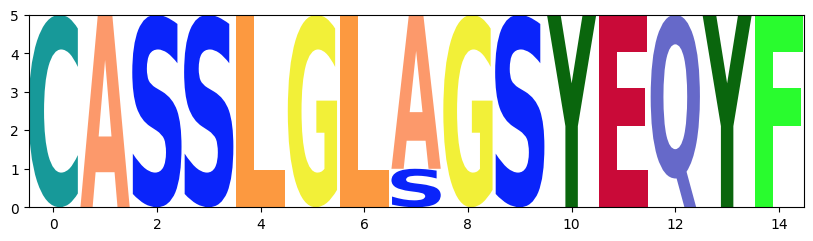

In [113]:
plot_logo(df[df.merged_cluster_id == 3655].cdr3aa_beta)

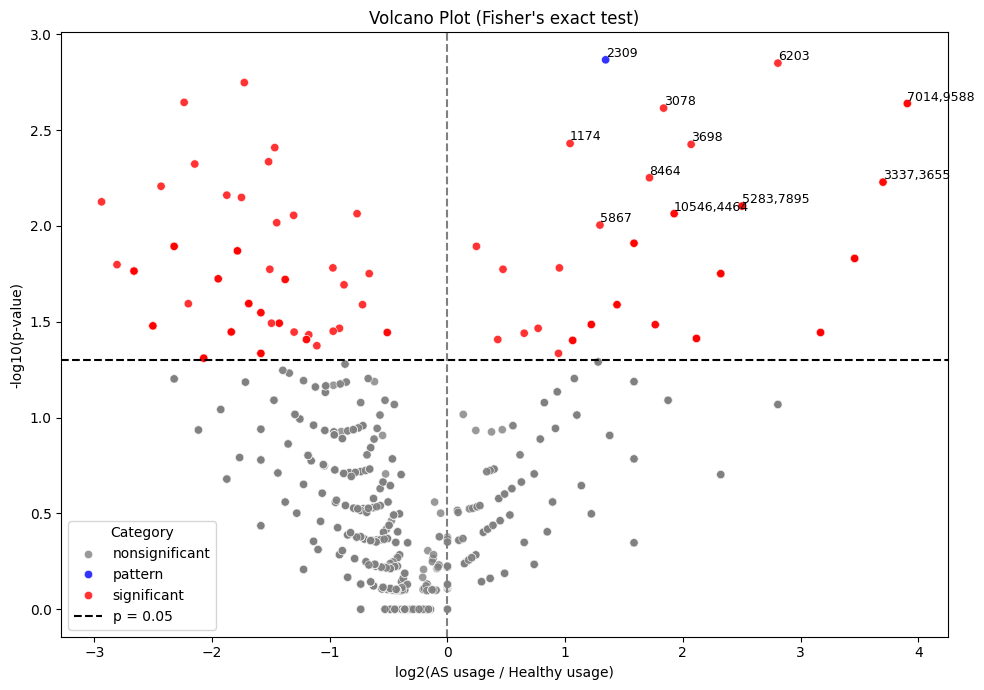

In [114]:
plot_volcano(summary)


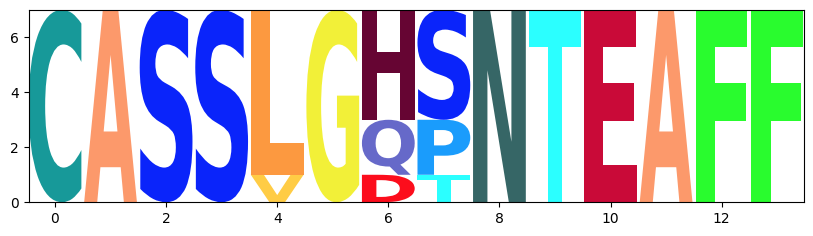

In [115]:
plot_logo(df[df.merged_cluster_id == 6203].cdr3aa_beta)

In [116]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
1084,1084,1242,22,False,6.534613e-07,693,549,0.442029,0.557971,27,33,1.000000
267,267,681,20,False,5.824201e-07,384,297,0.436123,0.563877,27,33,1.000000
4,4,698,18,False,4.251389e-07,322,376,0.538682,0.461318,27,33,1.000000
609,609,765,17,False,1.981194e-07,304,461,0.602614,0.397386,27,33,1.000000
241,241,592,17,False,2.214852e-07,291,301,0.508446,0.491554,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
10610,10610,3,1,False,6.506542e-10,1,2,0.666667,0.333333,1,2,1.000000
10613,10613,3,1,False,2.901185e-07,1,2,0.666667,0.333333,1,1,1.000000
10614,10614,3,1,False,1.323308e-08,1,2,0.666667,0.333333,1,2,1.000000
10615,10615,3,1,False,2.225843e-07,1,2,0.666667,0.333333,1,1,1.000000


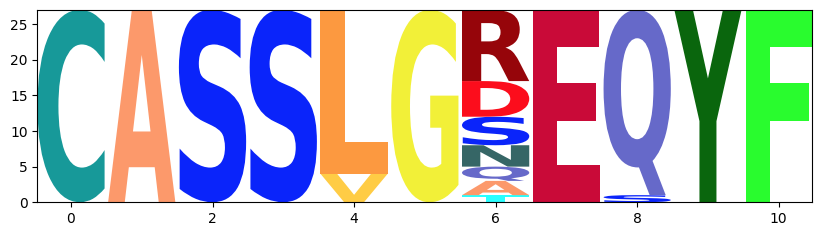

In [117]:
plot_logo(df[df.merged_cluster_id == 2856].cdr3aa_beta)

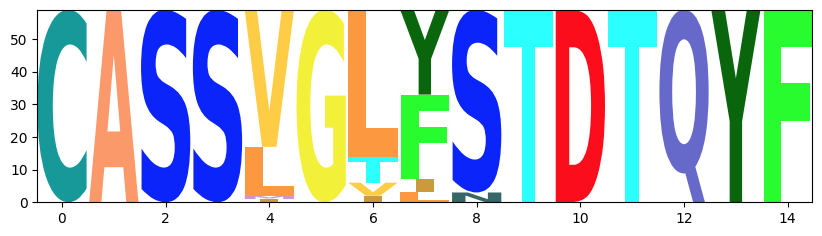

In [118]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

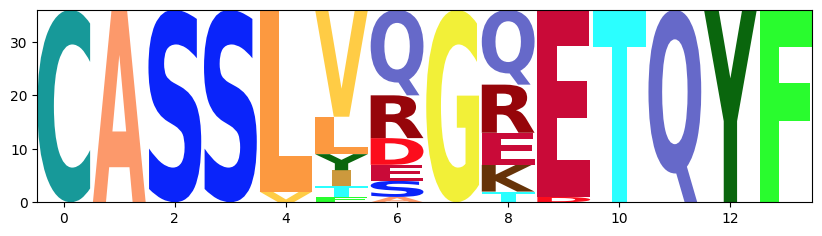

In [119]:
plot_logo(df[df.merged_cluster_id == 870].cdr3aa_beta)

In [120]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
82859,b_855721,as_i70_PB_F_c3462,CASSYTDTQYF,TRBV28*01,TRBJ2-3*01,background,as_i70_PB_F,False,3827,False,8.020229e-07
82860,b_856159,as_i70_PB_F_c279,CASSQAYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.476498e-06
82861,b_856238,as_i70_PB_F_c279,CASSTSYEQYF,TRBV3-1*01,TRBJ2-7*01,background,as_i70_PB_F,False,594,False,1.801972e-06
82862,b_857090,as_i70_PB_F_c292,CSVELGYGYTF,TRBV29-1*01,TRBJ1-2*01,background,as_i70_PB_F,False,10495,False,1.065633e-08


In [121]:
pgen_df = df.groupby('merged_cluster_id').agg({
    'pgen': 'mean'
}).reset_index()
pgen_df

,merged_cluster_id,pgen
0,0,2.085561e-07
1,1,9.632566e-07
2,2,8.828989e-09
3,3,3.806336e-08
4,4,4.251389e-07
...,...,...
10614,10614,1.323308e-08
10615,10615,2.225843e-07
10616,10616,4.372124e-07
10617,10617,3.641572e-08


In [122]:
pgen_df['log_pgen'] = np.log10(pgen_df.pgen)

In [123]:
pgen_df

,merged_cluster_id,pgen,log_pgen
0,0,2.085561e-07,-6.680777
1,1,9.632566e-07,-6.016258
2,2,8.828989e-09,-8.054089
3,3,3.806336e-08,-7.419493
4,4,4.251389e-07,-6.371469
...,...,...,...
10614,10614,1.323308e-08,-7.878339
10615,10615,2.225843e-07,-6.652505
10616,10616,4.372124e-07,-6.359308
10617,10617,3.641572e-08,-7.438711


In [124]:
summary = summary.merge(pgen_df[['merged_cluster_id', 'log_pgen']])
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen
0,1084,1242,22,False,6.534613e-07,693,549,0.442029,0.557971,27,33,1.000000,-6.184780
1,267,681,20,False,5.824201e-07,384,297,0.436123,0.563877,27,33,1.000000,-6.234764
2,4,698,18,False,4.251389e-07,322,376,0.538682,0.461318,27,33,1.000000,-6.371469
3,609,765,17,False,1.981194e-07,304,461,0.602614,0.397386,27,33,1.000000,-6.703073
4,241,592,17,False,2.214852e-07,291,301,0.508446,0.491554,27,33,1.000000,-6.654655
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10614,10610,3,1,False,6.506542e-10,1,2,0.666667,0.333333,1,2,1.000000,-9.186650
10615,10613,3,1,False,2.901185e-07,1,2,0.666667,0.333333,1,1,1.000000,-6.537425
10616,10614,3,1,False,1.323308e-08,1,2,0.666667,0.333333,1,2,1.000000,-7.878339
10617,10615,3,1,False,2.225843e-07,1,2,0.666667,0.333333,1,1,1.000000,-6.652505


In [125]:
summary['patient_fc'] = ((summary.as_usage + 1) / 28) / ((summary.h_usage + 1)/ 34)
summary['log_patient_fc'] = np.log10(summary['patient_fc'])

In [126]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [127]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def compute_topsis_score(df: pd.DataFrame, metric_types: dict, weight_dict: dict = None):
    df = df.copy()
    metrics = list(metric_types.keys())

    # Шаг 1: Нормализация
    norm_df = df[metrics].copy()
    scaler = MinMaxScaler()
    norm_df[metrics] = scaler.fit_transform(norm_df[metrics])

    # Шаг 2: Учет направлений метрик
    for col, kind in metric_types.items():
        if kind == 'cost':
            norm_df[col] = 1 - norm_df[col]

    # Шаг 3: Применение весов (по умолчанию — равные)
    if weight_dict is None:
        weights = np.ones(len(metrics)) / len(metrics)
    else:
        weights = np.array([weight_dict[m] for m in metrics])
        weights = weights / weights.sum()  # нормализация весов
    weighted = norm_df * weights

    # Шаг 4: Расчет расстояний до идеала и анти-идеала
    ideal = weighted.max()
    anti_ideal = weighted.min()

    d_pos = np.linalg.norm(weighted - ideal, axis=1)
    d_neg = np.linalg.norm(weighted - anti_ideal, axis=1)

    # Шаг 5: Финальный TOPSIS скор
    score = d_neg / (d_pos + d_neg)
    # score = (score - score.min()) / (score.max() - score.min()) 
    df["topsis_score"] = score

    return df.sort_values("topsis_score", ascending=False).reset_index(drop=True)


In [128]:
selected_summary  = summary[summary.log_patient_fc > 0]
selected_summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size
13,1207,61,11,False,1.933779e-07,16,45,0.737705,0.262295,22,26,1.000000,-6.713593,1.034392,0.014685,1.785330
14,34,153,10,False,1.639226e-07,51,102,0.666667,0.333333,25,30,1.000000,-6.785361,1.018433,0.007933,2.184691
16,571,100,10,False,1.168129e-06,31,69,0.690000,0.310000,26,30,0.619945,-5.932509,1.057604,0.024323,2.000000
19,730,68,10,False,1.045257e-07,22,46,0.676471,0.323529,21,25,1.000000,-6.980777,1.027473,0.011770,1.832509
20,922,60,10,False,5.435052e-07,25,35,0.583333,0.416667,24,29,1.000000,-6.264796,1.011905,0.005140,1.778151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10609,10597,3,1,False,7.457139e-10,1,2,0.666667,0.333333,2,1,0.583402,-9.127428,1.821429,0.260412,0.477121
10612,10604,3,1,False,1.871057e-07,1,2,0.666667,0.333333,1,1,1.000000,-6.727913,1.214286,0.084321,0.477121
10615,10613,3,1,False,2.901185e-07,1,2,0.666667,0.333333,1,1,1.000000,-6.537425,1.214286,0.084321,0.477121
10617,10615,3,1,False,2.225843e-07,1,2,0.666667,0.333333,1,1,1.000000,-6.652505,1.214286,0.084321,0.477121


In [129]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    'log_pgen': 'cost',
    'log_patient_fc': 'benefit',
}

custom_weights = {
    'n_patients': 1.25,
    'sample_fraction': 1,
    'log_cluster_size': 2,
    'log_pgen': 1.0,
    'log_patient_fc': 1.5,
}

ranked_df = compute_topsis_score(selected_summary, metrics, weight_dict=custom_weights)
ranked_df.head(20)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size,topsis_score
0,2309,59,9,True,4.064005e-09,11,48,0.813559,0.186441,16,6,0.001360,-8.391046,2.948980,0.469672,1.770852,0.587855
1,34,153,10,False,1.639226e-07,51,102,0.666667,0.333333,25,30,1.000000,-6.785361,1.018433,0.007933,2.184691,0.528674
2,571,100,10,False,1.168129e-06,31,69,0.690000,0.310000,26,30,0.619945,-5.932509,1.057604,0.024323,2.000000,0.503680
3,1207,61,11,False,1.933779e-07,16,45,0.737705,0.262295,22,26,1.000000,-6.713593,1.034392,0.014685,1.785330,0.495647
4,4744,224,5,False,1.192191e-08,108,116,0.517857,0.482143,26,31,1.000000,-7.923654,1.024554,0.010535,2.350248,0.492190
5,4503,411,2,False,1.111606e-08,228,183,0.445255,0.554745,27,32,1.000000,-7.954049,1.030303,0.012965,2.613842,0.489709
6,730,68,10,False,1.045257e-07,22,46,0.676471,0.323529,21,25,1.000000,-6.980777,1.027473,0.011770,1.832509,0.486101
7,80,53,10,False,2.110276e-07,14,39,0.735849,0.264151,24,27,0.494781,-6.675661,1.084184,0.035103,1.724276,0.478165
8,272,78,9,False,1.037116e-06,24,54,0.692308,0.307692,25,30,1.000000,-5.984173,1.018433,0.007933,1.892095,0.475624
9,922,60,10,False,5.435052e-07,25,35,0.583333,0.416667,24,29,1.000000,-6.264796,1.011905,0.005140,1.778151,0.462698


In [130]:
ranked_df[['as_pattern', 'merged_cluster_id', 'cluster_size', 
           'n_patients', 'background', 'sample', 'sample_fraction', 
           'as_usage', 'h_usage', 'log_pgen', 'patient_fc', 'topsis_score']].head(20)

,as_pattern,merged_cluster_id,cluster_size,n_patients,background,sample,sample_fraction,as_usage,h_usage,log_pgen,patient_fc,topsis_score
0,True,2309,59,9,11,48,0.813559,16,6,-8.391046,2.948980,0.587855
1,False,34,153,10,51,102,0.666667,25,30,-6.785361,1.018433,0.528674
2,False,571,100,10,31,69,0.690000,26,30,-5.932509,1.057604,0.503680
3,False,1207,61,11,16,45,0.737705,22,26,-6.713593,1.034392,0.495647
4,False,4744,224,5,108,116,0.517857,26,31,-7.923654,1.024554,0.492190
5,False,4503,411,2,228,183,0.445255,27,32,-7.954049,1.030303,0.489709
6,False,730,68,10,22,46,0.676471,21,25,-6.980777,1.027473,0.486101
7,False,80,53,10,14,39,0.735849,24,27,-6.675661,1.084184,0.478165
8,False,272,78,9,24,54,0.692308,25,30,-5.984173,1.018433,0.475624
9,False,922,60,10,25,35,0.583333,24,29,-6.264796,1.011905,0.462698


In [131]:
df[df.merged_cluster_id == 7446]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
55842,s_1204,as_Mart_PB_F_c128,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Mart_PB_F,False,7446,False,7.092919e-08
55867,s_3301,as_Mart_PB_F_c128,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Mart_PB_F,False,7446,False,7.092919e-08
55969,s_20028,as_Mart_PB_F_c128,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Mart_PB_F,False,7446,False,7.092919e-08
55970,s_20030,as_Mart_PB_F_c128,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Mart_PB_F,False,7446,False,7.092919e-08
62466,s_932,as_Shep_PB_F_c143,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Shep_PB_F,False,7446,False,7.092919e-08
62481,s_1659,as_Shep_PB_F_c143,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Shep_PB_F,False,7446,False,7.092919e-08
64033,s_234128,as_Shep_PB_F_c143,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Shep_PB_F,False,7446,False,7.092919e-08
70615,s_450,as_Uv_PB_F_c66,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Uv_PB_F,False,7446,False,7.092919e-08
70627,s_1316,as_Uv_PB_F_c66,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Uv_PB_F,False,7446,False,7.092919e-08
70662,s_3073,as_Uv_PB_F_c66,CASSFLGGTYEQYF,TRBV5-1*01,TRBJ2-7*01,sample,as_Uv_PB_F,False,7446,False,7.092919e-08


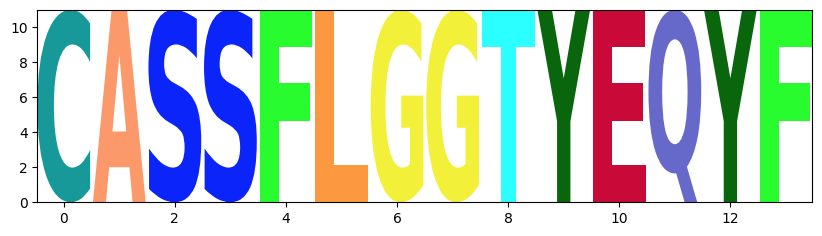

In [132]:
plot_logo(df[df.merged_cluster_id == 7446].cdr3aa_beta)

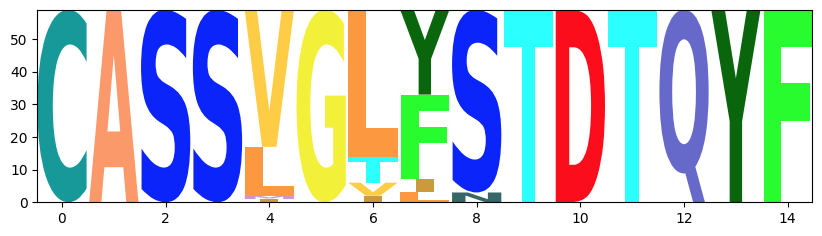

In [133]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [134]:
ranked_df[ranked_df['as_pattern']]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size,topsis_score
0,2309,59,9,True,4.064005e-09,11,48,0.813559,0.186441,16,6,0.001360,-8.391046,2.948980,0.469672,1.770852,0.587855
15,4992,7,2,True,3.462544e-09,0,7,1.000000,0.000000,5,0,0.014782,-8.460605,7.285714,0.862472,0.845098,0.449670


<Axes: xlabel='log_patient_fc', ylabel='Count'>

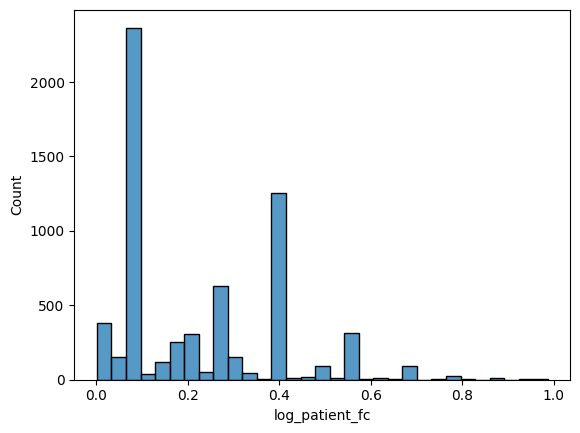

In [135]:
sns.histplot(selected_summary.log_patient_fc)